# Per-Layer Exploratory Data Analysis

This notebook performs EDA separately for each omics layer (MGX, metabolomics, host transcriptomics) prior to network inference with Graphical LASSO.

**METHOD**

Each layer is already reduced to the final, differentially abundant/expressed feature set produced by `pipeline.ipynb` (i.e. the same features that are actually used as GLASSO nodes), aggregated to one row per participant. Each layer section follows the same template: load & align, distributional diagnostics (missingness/zero-inflation, summary statistics, distribution, scale, normality, outliers), correlation structure, and sample-level structure (PCA). A final section synthesises the normality/scale findings and their implications for Graphical LASSO, followed by a cross-layer participant-overlap analysis.

**RUN**

Diagnostic only -- not part of the required pipeline chain. Run any time after Stage 1 (`01_run_pipeline.py`), interactively top to bottom.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

DATA_DIR = "Data"
METADATA_PATH = f"{DATA_DIR}/hmp2_metadata_2018-08-20.csv"
metadata = pd.read_csv(METADATA_PATH, low_memory=False)

# Participant-level metadata (diagnosis, site), deduplicated. All three processed
# layers below are already aggregated to one row per Participant ID, so alignment
# must happen at the participant level, not the sample (External ID) level.
participant_meta = (
    metadata[["Participant ID", "diagnosis", "site_name"]]
    .drop_duplicates(subset="Participant ID")
    .set_index("Participant ID")
)


def normality_summary(df, alpha=0.05):
    """Per-feature skewness, kurtosis and Shapiro-Wilk test as a DataFrame."""
    rows = []
    for col in df.columns:
        x = df[col].dropna().values
        sh_stat, sh_p = stats.shapiro(x)
        rows.append({
            "feature": col,
            "skew": stats.skew(x),
            "kurtosis": stats.kurtosis(x),
            "shapiro_p": sh_p,
            "reject_normal": sh_p < alpha,
        })
    return pd.DataFrame(rows).set_index("feature")

## 1. Metagenomics (MGX)

Source: `Data/mgx_species_clr_processed.csv` — the differentially abundant species selected in `pipeline.ipynb` (Kruskal-Wallis across diagnosis groups), already CLR-transformed and aggregated to one row per participant. Zeros have been mapped to a per-sample floor value (the CLR floor depends on each sample's geometric mean, so it varies by row), which shows up as a point mass in the distribution and normality checks below.

### 1.1 Load data and align with metadata

In [2]:
mgx = pd.read_csv(f"{DATA_DIR}/mgx_species_clr_processed.csv", index_col=0)
mgx.index.name = "Participant ID"

mgx_meta = participant_meta.reindex(mgx.index)
print(f"MGX participants: {mgx.shape[0]}, matched metadata: {mgx_meta['diagnosis'].notna().sum()}")
mgx_meta.head()

MGX participants: 130, matched metadata: 130


,diagnosis,site_name
Participant ID,,
C3001,CD,Cedars-Sinai
C3002,CD,Cedars-Sinai
C3003,UC,Cedars-Sinai
C3004,UC,Cedars-Sinai
C3005,UC,Cedars-Sinai


### 1.2 Distributional diagnostics

**Shape and structure.**

In [3]:
print("Shape:", mgx.shape)
print(mgx.dtypes.value_counts())
mgx.head()

Shape: (130, 25)
float64    25
Name: count, dtype: int64


,Eisenbergiella_massiliensis,Clostridium_bolteae_CAG_59,Clostridium_lavalense,Hungatella_hathewayi,Clostridium_clostridioforme,Veillonella_atypica,Streptococcus_parasanguinis,Clostridium_symbiosum,Anaerotruncus_colihominis,Ruminococcus_gnavus,...,Bacteroides_fragilis,Roseburia_inulinivorans,Ruminococcus_bicirculans,Intestinimonas_butyriciproducens,Odoribacter_splanchnicus,Anaeromassilibacillus_sp_An250,Ruminococcus_torques,Veillonella_parvula,Escherichia_coli,Eubacterium_eligens
Participant ID,,,,,,,,,,,,,,,,,,,,,
C3001,2.329844,2.794706,-2.778941,-2.700169,6.280998,-2.778941,-2.778941,-2.263689,3.397800,1.204787,...,7.526965,3.759169,1.551346,4.187582,-2.778941,-2.778941,2.102441,-2.778941,3.722265,-2.734379
C3002,-1.687066,-1.687066,6.071064,-1.687066,7.887464,-1.687066,-1.687066,-1.596080,-1.687066,-1.521546,...,10.019026,-1.596080,-1.596080,-1.687066,-1.687066,-1.687066,-1.687066,-1.687066,2.312673,-1.582660
C3003,-3.595766,-3.537832,-2.770108,-3.595766,2.082139,-3.595766,-3.595766,-1.371212,-3.130844,4.129688,...,0.674729,-3.595766,-3.595766,-3.130844,4.725207,0.757368,-3.595766,-3.595766,-3.537832,-3.595766
C3004,3.202437,-3.262803,1.071975,-3.465429,-0.619027,-3.562040,-3.524497,-3.403372,2.252770,0.440857,...,-3.507675,4.985216,-3.507675,1.826731,-3.507675,-0.076438,-3.562040,-3.562040,-3.513575,3.386972
C3005,-0.190659,-3.937300,1.936231,-3.937300,-1.095459,-4.154714,-4.154714,-3.937300,-3.937300,-3.937300,...,3.173038,1.619680,2.038688,2.559301,-4.146082,-2.783554,-4.154714,-4.154714,5.506091,3.489167


**Missingness and zero-inflation.**\n\nCheck for NaNs, and separately quantify the proportion of participants at each species' per-sample CLR floor (this represents zero abundance pre-transform).

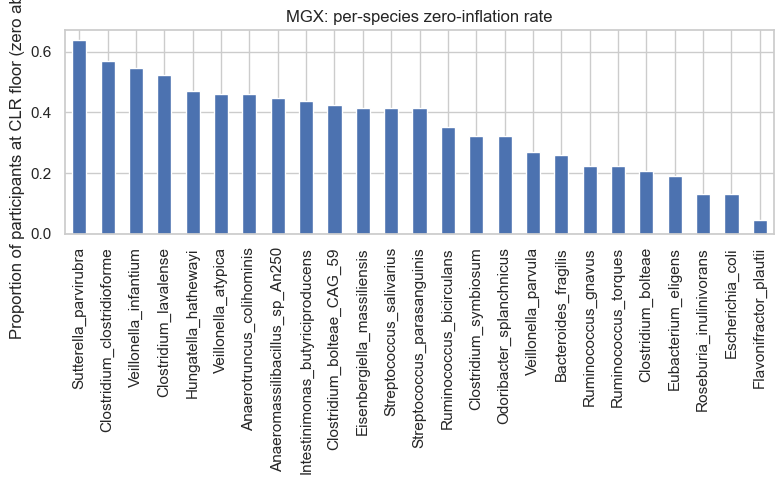

Max NaNs in any feature: 0


,zero_rate
Sutterella_parvirubra,0.638462
Clostridium_clostridioforme,0.569231
Veillonella_infantium,0.546154
Clostridium_lavalense,0.523077
Hungatella_hathewayi,0.469231
Veillonella_atypica,0.461538
Anaerotruncus_colihominis,0.461538
Anaeromassilibacillus_sp_An250,0.446154
Intestinimonas_butyriciproducens,0.438462
Clostridium_bolteae_CAG_59,0.423077


In [4]:
# Per-participant CLR floor = that row's minimum value (zero-replacement constant).
# Valid as an "at floor" (zero-abundance) indicator provided at least one species
# is genuinely absent in each row, which holds given known microbiome sparsity.
row_floor = mgx.min(axis=1)
at_floor = mgx.eq(row_floor, axis=0)
zero_rate_mgx = at_floor.mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
zero_rate_mgx.plot(kind="bar", ax=ax)
ax.set_ylabel("Proportion of participants at CLR floor (zero abundance)")
ax.set_title("MGX: per-species zero-inflation rate")
plt.tight_layout()
plt.show()

print("Max NaNs in any feature:", mgx.isna().sum().max())
zero_rate_mgx.to_frame("zero_rate")

**Summary statistics.**

In [5]:
mgx.describe().T

,count,mean,std,min,25%,50%,75%,max
Eisenbergiella_massiliensis,130.0,-1.785980,3.093752,-5.601861,-3.842673,-3.060134,-0.640609,6.744862
Clostridium_bolteae_CAG_59,130.0,-2.599101,2.391854,-5.601861,-3.970188,-3.365249,-2.234688,7.531526
Clostridium_lavalense,130.0,-2.416545,2.330510,-5.624217,-3.917970,-3.051152,-1.815238,6.071064
Hungatella_hathewayi,130.0,-2.253318,2.681461,-5.624217,-3.913932,-3.201753,-1.876652,6.023038
Clostridium_clostridioforme,130.0,-2.004750,3.395283,-5.624217,-4.117244,-3.355223,-1.839671,10.015548
Veillonella_atypica,130.0,-2.228847,2.723983,-5.624217,-3.881628,-3.299912,-1.789886,10.127520
Streptococcus_parasanguinis,130.0,-2.349644,2.214171,-5.624217,-3.847710,-3.100335,-1.653822,4.727569
Clostridium_symbiosum,130.0,-1.233169,3.413094,-5.624217,-3.847710,-2.898021,1.489030,7.170999
Anaerotruncus_colihominis,130.0,-2.565518,2.082660,-5.624217,-3.860760,-3.140412,-2.075271,5.812621
Ruminococcus_gnavus,130.0,0.217650,4.020874,-5.624217,-3.557573,-0.261594,3.362755,9.929781


**Distribution.**

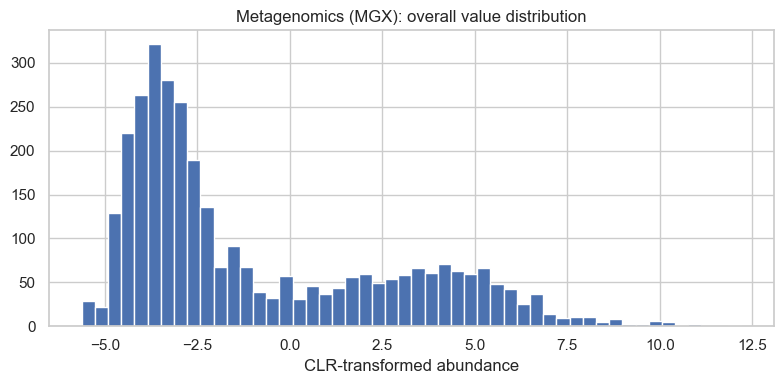

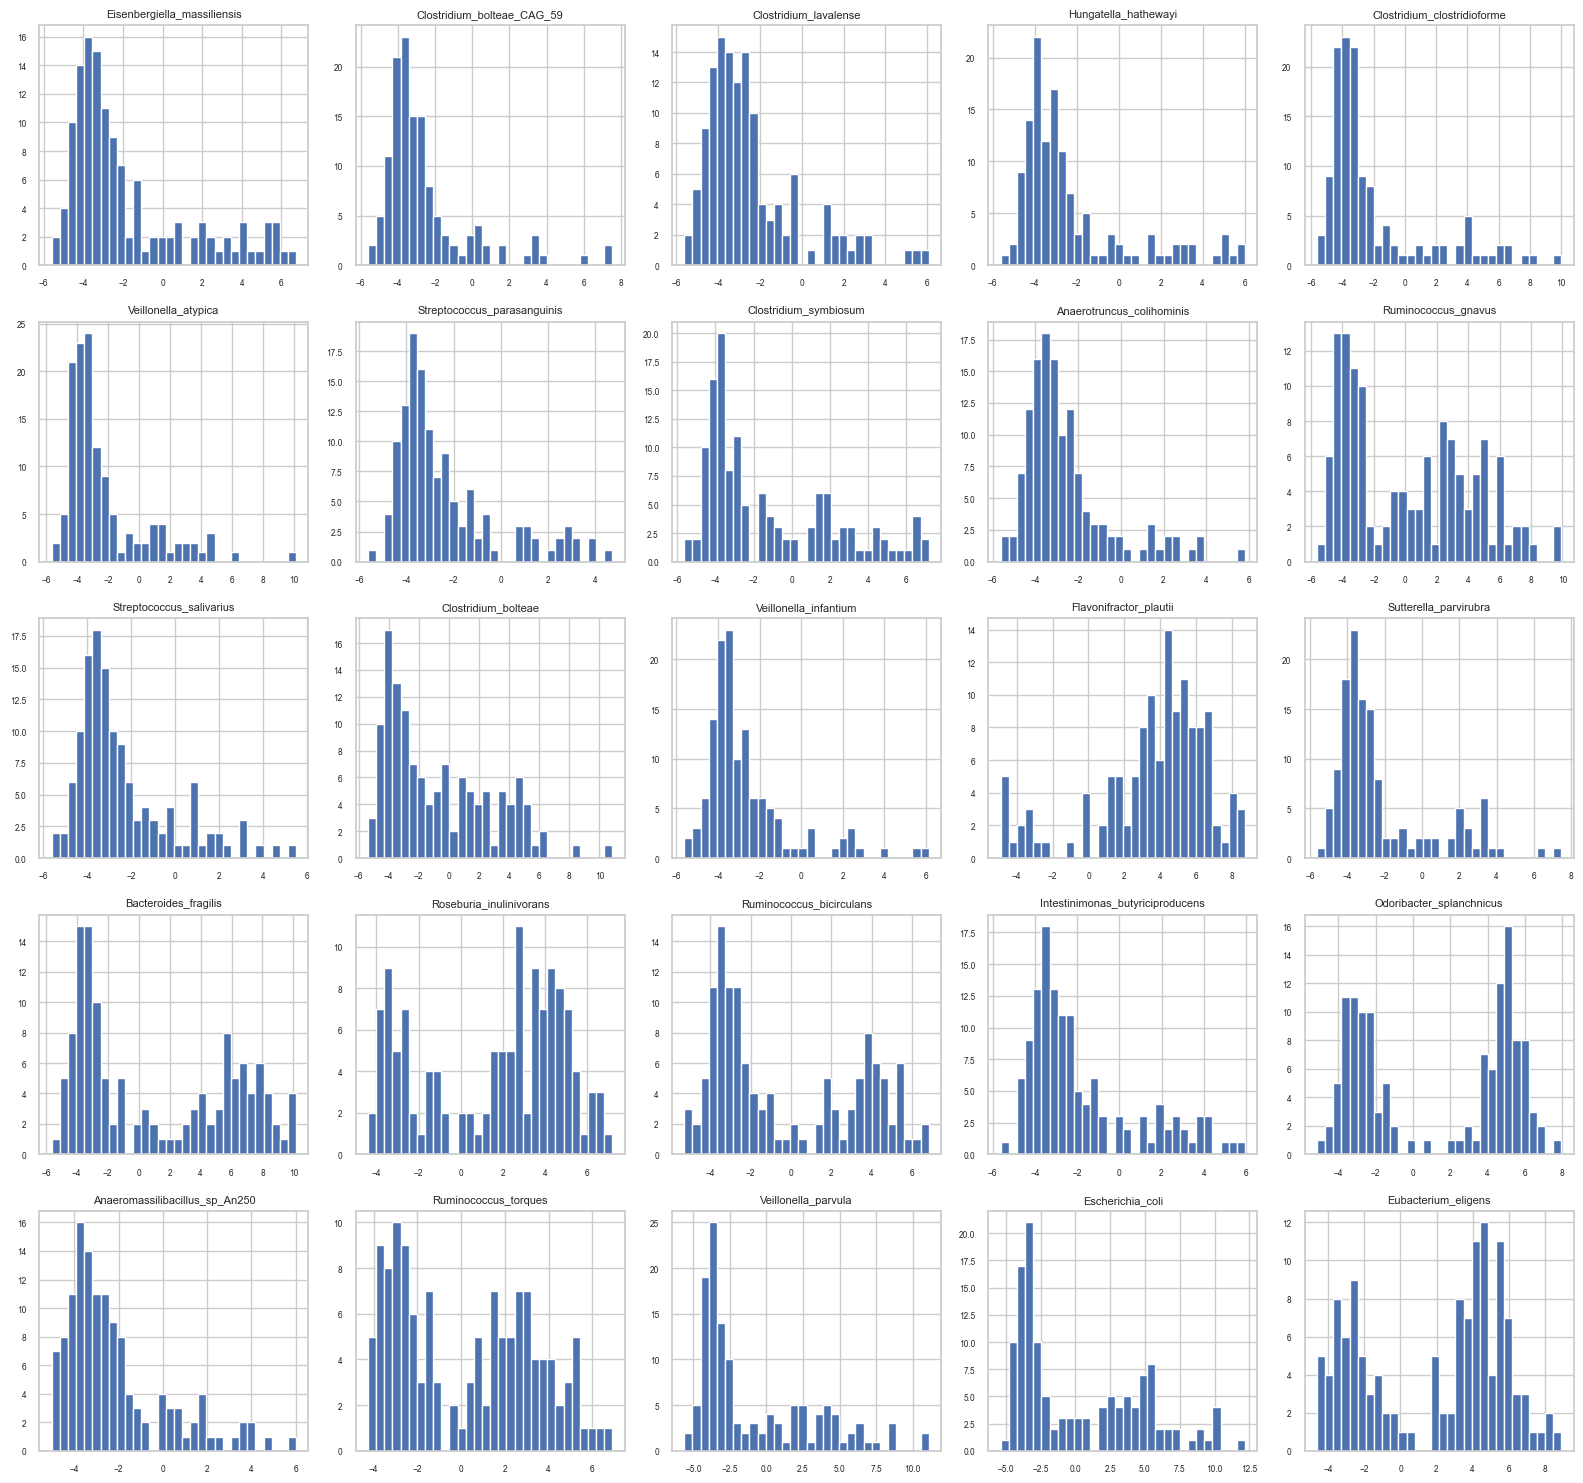

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mgx.values.flatten(), bins=50)
ax.set_title("Metagenomics (MGX): overall value distribution")
ax.set_xlabel("CLR-transformed abundance")
plt.tight_layout()
plt.show()

n_feat = mgx.shape[1]
ncols = 5
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
for ax, col in zip(np.array(axes).flat, mgx.columns):
    ax.hist(mgx[col], bins=30)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)
for ax in np.array(axes).flat[n_feat:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Scale.** Per-feature variance/range — relevant for whether standardisation is needed before Graphical LASSO.

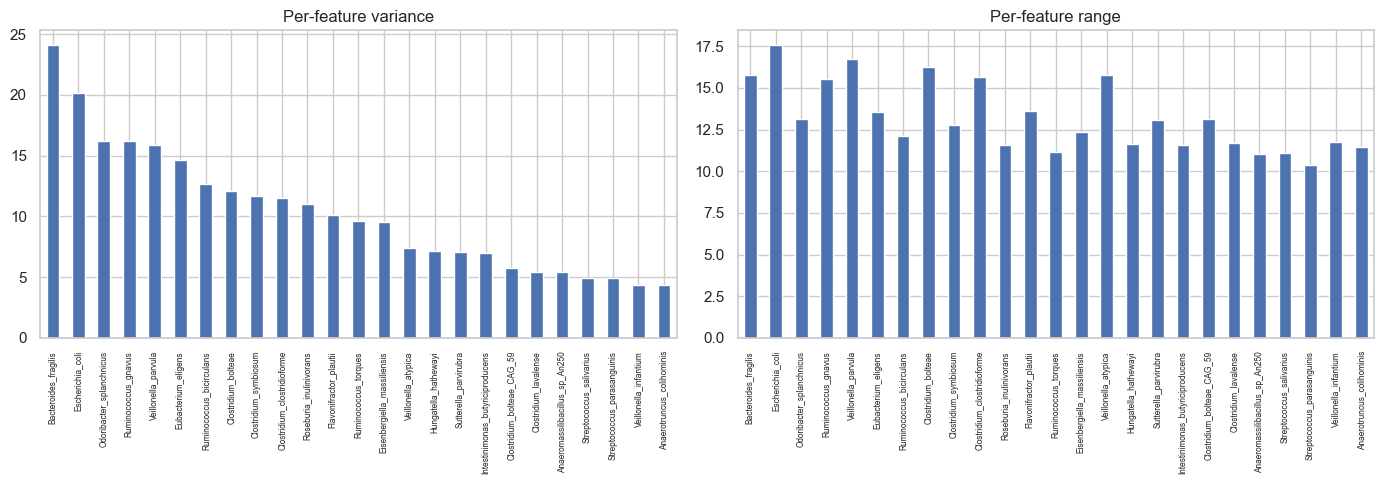

,variance,range
Bacteroides_fragilis,24.104507,15.798748
Escherichia_coli,20.155439,17.570902
Odoribacter_splanchnicus,16.225485,13.114609
Ruminococcus_gnavus,16.167427,15.553998
Veillonella_parvula,15.892386,16.731309
Eubacterium_eligens,14.638289,13.541938
Ruminococcus_bicirculans,12.640264,12.141793
Clostridium_bolteae,12.064483,16.236453
Clostridium_symbiosum,11.649212,12.795216
Clostridium_clostridioforme,11.527950,15.639766


In [7]:
scale_mgx = pd.DataFrame({
    "variance": mgx.var(),
    "range": mgx.max() - mgx.min(),
}).sort_values("variance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scale_mgx["variance"].plot(kind="bar", ax=axes[0], title="Per-feature variance")
scale_mgx["range"].plot(kind="bar", ax=axes[1], title="Per-feature range")
for ax in axes:
    ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

scale_mgx

**Normality.** Per-feature skewness/kurtosis, Q-Q plots for a representative subset, and Shapiro-Wilk results, cross-tabulated against the zero-inflation rate above.

Features rejecting normality (Shapiro, alpha=0.05): 25 / 25 (100.0%)


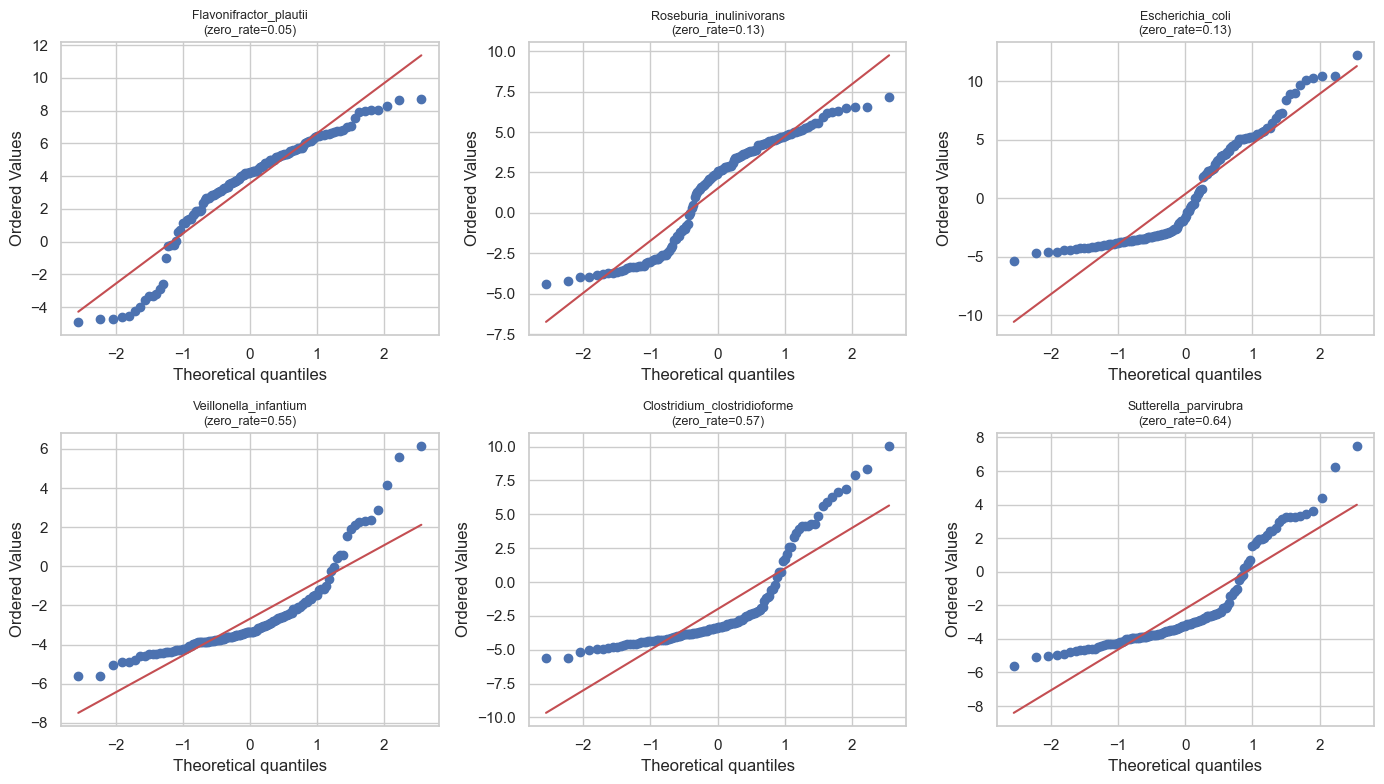

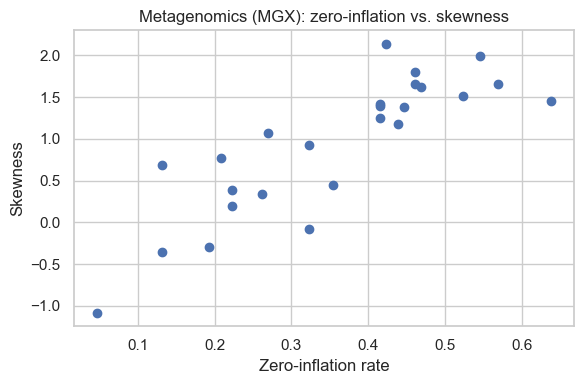

,skew,kurtosis,shapiro_p,reject_normal,zero_rate
feature,,,,,
Sutterella_parvirubra,1.451469,1.320292,1.141171e-11,True,0.638462
Clostridium_clostridioforme,1.660343,1.821608,2.537570e-13,True,0.569231
Veillonella_infantium,1.990304,4.336525,3.197406e-12,True,0.546154
Clostridium_lavalense,1.516429,2.130343,5.162506e-10,True,0.523077
Hungatella_hathewayi,1.625001,1.733426,1.139909e-12,True,0.469231
Veillonella_atypica,1.796828,3.317374,3.062627e-12,True,0.461538
Anaerotruncus_colihominis,1.655971,2.705250,1.064575e-10,True,0.461538
Anaeromassilibacillus_sp_An250,1.381083,1.366172,6.083628e-10,True,0.446154
Intestinimonas_butyriciproducens,1.175015,0.349864,5.476066e-10,True,0.438462


In [8]:
norm_mgx = normality_summary(mgx).join(zero_rate_mgx.rename("zero_rate"))
print(f"Features rejecting normality (Shapiro, alpha=0.05): "
      f"{norm_mgx['reject_normal'].sum()} / {len(norm_mgx)} "
      f"({norm_mgx['reject_normal'].mean():.1%})")

example_cols = (
    norm_mgx.sort_values("zero_rate").index[:3].tolist()
    + norm_mgx.sort_values("zero_rate").index[-3:].tolist()
)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, example_cols):
    stats.probplot(mgx[col], dist="norm", plot=ax)
    ax.set_title(f"{col}\n(zero_rate={norm_mgx.loc[col, 'zero_rate']:.2f})", fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(norm_mgx["zero_rate"], norm_mgx["skew"])
ax.set_xlabel("Zero-inflation rate")
ax.set_ylabel("Skewness")
ax.set_title("Metagenomics (MGX): zero-inflation vs. skewness")
plt.tight_layout()
plt.show()

norm_mgx.sort_values("zero_rate", ascending=False)

**Outliers.**

Per-feature outlier rate (|z| > 3):
Veillonella_infantium               0.023077
Clostridium_lavalense               0.023077
Clostridium_bolteae_CAG_59          0.023077
Streptococcus_salivarius            0.015385
Sutterella_parvirubra               0.015385
Anaerotruncus_colihominis           0.015385
Veillonella_atypica                 0.015385
Clostridium_clostridioforme         0.015385
Streptococcus_parasanguinis         0.007692
Clostridium_bolteae                 0.007692
Hungatella_hathewayi                0.007692
Anaeromassilibacillus_sp_An250      0.007692
Escherichia_coli                    0.000000
Intestinimonas_butyriciproducens    0.000000
Veillonella_parvula                 0.000000
Ruminococcus_torques                0.000000
Odoribacter_splanchnicus            0.000000
Eisenbergiella_massiliensis         0.000000
Ruminococcus_bicirculans            0.000000
Roseburia_inulinivorans             0.000000
Bacteroides_fragilis                0.000000
Flavonifractor_plau

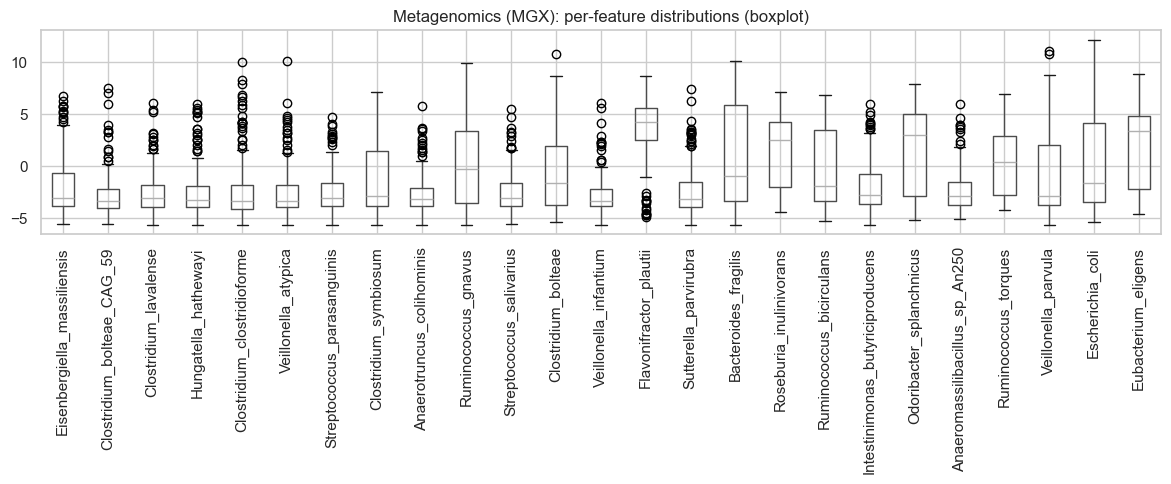

In [9]:
z_mgx = (mgx - mgx.mean()) / mgx.std()
outlier_rate_mgx = (z_mgx.abs() > 3).mean().sort_values(ascending=False)
print("Per-feature outlier rate (|z| > 3):")
print(outlier_rate_mgx)

fig, ax = plt.subplots(figsize=(12, 5))
mgx.boxplot(ax=ax, rot=90)
ax.set_title("Metagenomics (MGX): per-feature distributions (boxplot)")
plt.tight_layout()
plt.show()

### 1.3 Correlation structure\n\nPearson vs. Spearman correlation heatmaps side by side — large divergence between the two indicates non-linear/non-Gaussian relationships.

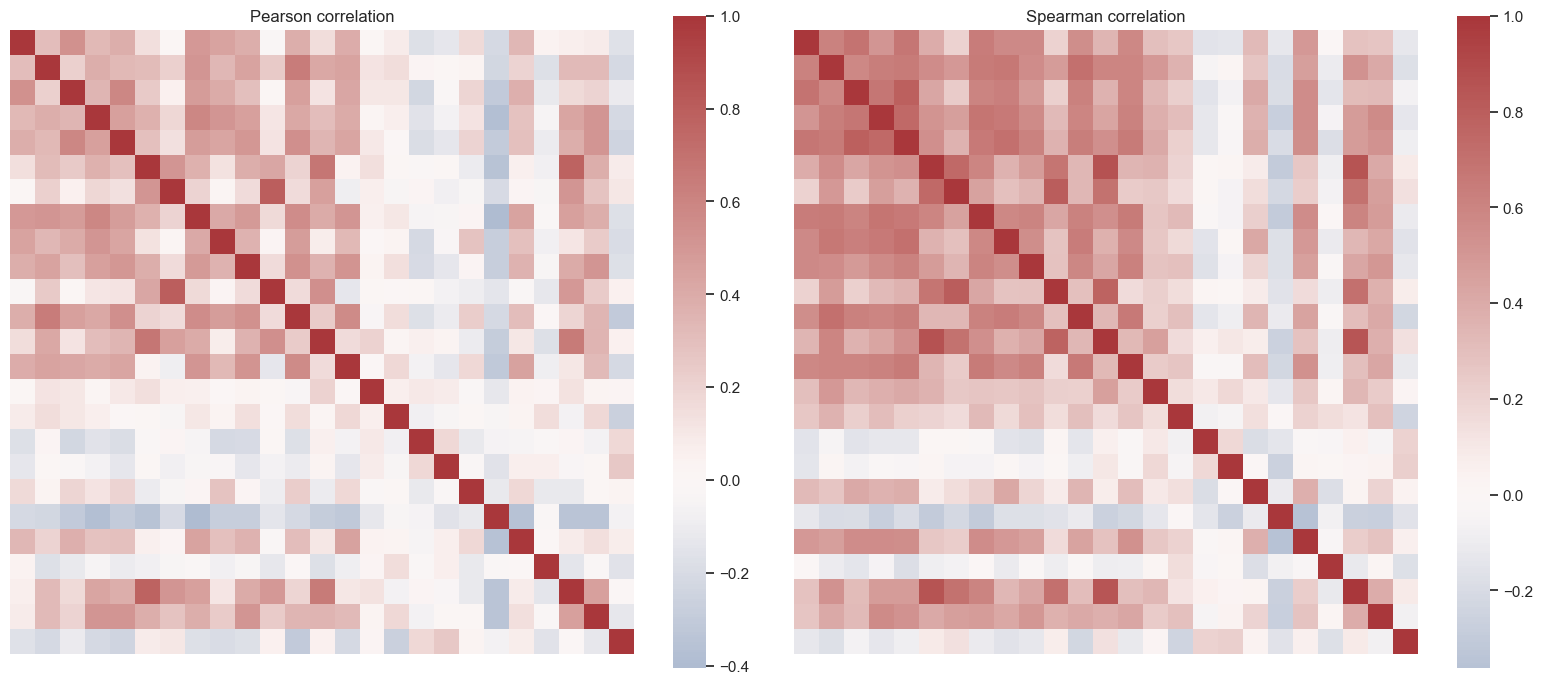

Mean |Pearson - Spearman| difference: 0.12628124222123266


In [10]:
pearson_mgx = mgx.corr(method="pearson")
spearman_mgx = mgx.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(pearson_mgx, ax=axes[0], cmap="vlag", center=0, square=True,
            xticklabels=False, yticklabels=False)
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman_mgx, ax=axes[1], cmap="vlag", center=0, square=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

print("Mean |Pearson - Spearman| difference:",
      (pearson_mgx - spearman_mgx).abs().values.mean())

### 1.4 Sample-level structure (PCA)\n\nPCA on the standardised feature table, coloured by diagnosis, to check for batch effects or cohort separation.

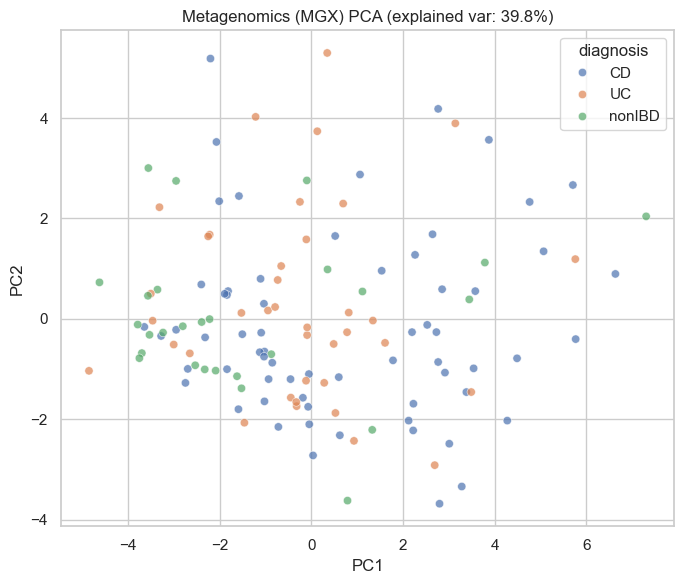

In [11]:
pca_mgx = PCA(n_components=2, random_state=0)
scores_mgx = pca_mgx.fit_transform(StandardScaler().fit_transform(mgx))
pca_mgx_df = pd.DataFrame(scores_mgx, columns=["PC1", "PC2"], index=mgx.index).join(mgx_meta)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_mgx_df, x="PC1", y="PC2", hue="diagnosis", ax=ax, alpha=0.7)
ax.set_title(f"Metagenomics (MGX) PCA (explained var: {pca_mgx.explained_variance_ratio_[:2].sum():.1%})")
plt.tight_layout()
plt.show()

### 1.5 Summary

The 25 CLR-transformed species retained by differential-abundance selection have no missing values, but show substantial zero-inflation: the per-species proportion of participants at the CLR floor (zero raw abundance) ranges from 4.6% (*Flavonifractor plautii*) to 63.8% (*Sutterella parvirubra*), with a mean of 35.6%. Shapiro-Wilk rejects normality for all 25 species (100%), and zero-inflation correlates strongly with skewness (r = 0.84): the most zero-inflated species (e.g. *Sutterella parvirubra*, skew = 1.45) are the most right-skewed, while the least zero-inflated species (*Flavonifractor plautii*) is instead left-skewed (skew = -1.08) rather than symmetric. Per-feature variance is moderately heterogeneous (coefficient of variation ≈ 0.50), so standardisation before Graphical LASSO is advisable. Given the universal normality rejection driven by the zero-inflation point mass, a nonparanormal (rank-based) transform on top of the existing CLR transform is recommended before Graphical LASSO (see Section 4).

## 2. Metabolomics (MBX)

Source: `Data/mbx_metabolomics_log_processed.csv` — the differentially abundant metabolites selected in `pipeline.ipynb`, already log2-transformed and aggregated to one row per participant. Below-detection-limit intensities were imputed to half the minimum detected value *before* log-transformation, so (unlike MGX) there are no literal `0.0` values left to check for; the imputed floor instead shows up as each metabolite's column minimum.

### 2.1 Load data and align with metadata

In [12]:
mbx = pd.read_csv(f"{DATA_DIR}/mbx_metabolomics_log_processed.csv", index_col=0)
mbx.index.name = "Participant ID"

mbx_meta = participant_meta.reindex(mbx.index)
print(f"MBX participants: {mbx.shape[0]}, matched metadata: {mbx_meta['diagnosis'].notna().sum()}")
mbx_meta.head()

MBX participants: 106, matched metadata: 106


,diagnosis,site_name
Participant ID,,
C3001,CD,Cedars-Sinai
C3002,CD,Cedars-Sinai
C3003,UC,Cedars-Sinai
C3004,UC,Cedars-Sinai
C3005,UC,Cedars-Sinai


### 2.2 Distributional diagnostics

**Shape and structure.**

In [13]:
print("Shape:", mbx.shape)
print(mbx.dtypes.value_counts())
mbx.head()

Shape: (106, 25)
float64    25
Name: count, dtype: int64


,C18n_QI382,C18n_QI7515,C18n_QI13633,C18n_QI10861,C18n_QI10930,C18n_QI3061,HILn_QI3132,C18n_QI7435,HILn_QI1958,C18n_QI851,...,HILn_QI2332,C18n_QI13541,C18n_QI663,HILn_QI3463,C18n_QI1722,C18n_QI944,HILn_QI3904,C18n_QI13626,HILp_QI6836,HILp_QI3060
Participant ID,,,,,,,,,,,,,,,,,,,,,
C3001,12.449074,14.748068,1.584963,15.628200,16.878468,4.189689,15.255613,1.584963,4.392317,13.144712,...,1.321928,11.361736,13.264711,10.679405,8.256278,1.807355,10.458248,2.906891,2.906891,15.513165
C3002,14.577143,22.761079,1.584963,22.643639,27.547669,12.760690,4.087463,20.108716,21.853604,18.101509,...,18.213041,15.593822,19.447543,2.584963,13.883376,13.139895,4.459432,10.075479,15.875705,21.391077
C3003,14.977682,22.516290,17.080578,17.591975,26.763275,20.397618,4.087463,17.594339,14.903882,19.488956,...,17.936017,19.948289,18.920696,2.584963,17.561817,13.829029,4.459432,16.486788,14.213560,22.815863
C3004,7.754888,12.845490,7.912889,14.739781,16.419878,7.442943,13.986286,7.734710,8.957102,14.188434,...,7.882643,11.054604,15.712823,10.516685,14.187507,1.807355,4.459432,7.614710,8.618386,17.384767
C3005,14.240121,20.591535,16.718573,17.596976,26.555242,18.887108,7.665336,12.319954,18.424068,19.646495,...,19.405545,20.106067,21.147296,2.584963,15.796471,12.459944,4.459432,15.888505,13.502956,22.099384


**Missingness and zero-inflation.**\n\nQuantify the proportion of participants at each metabolite's imputation floor (below-detection-limit values, imputed then logged).

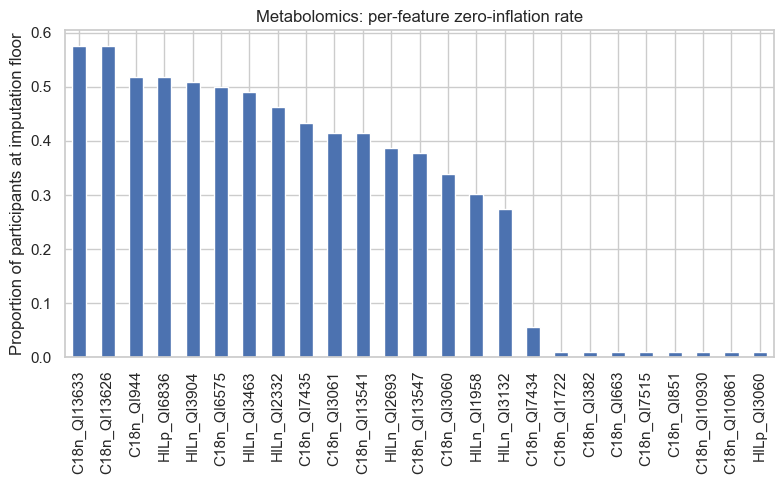

Max NaNs in any feature: 0


,zero_rate
C18n_QI13633,0.575472
C18n_QI13626,0.575472
C18n_QI944,0.518868
HILp_QI6836,0.518868
HILn_QI3904,0.509434
C18n_QI6575,0.500000
HILn_QI3463,0.490566
HILn_QI2332,0.462264
C18n_QI7435,0.433962
C18n_QI3061,0.415094


In [14]:
# Per-metabolite imputation floor = that column's minimum value, since values
# below detection were imputed to half the smallest real detection (guaranteed
# to be lower than any genuinely detected value). Checking exact `== 0` here
# would be a no-op, since imputation + log-transform leaves no literal zeros.
col_floor = mbx.min(axis=0)
at_floor = mbx.eq(col_floor, axis=1)
zero_rate_mbx = at_floor.mean(axis=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
zero_rate_mbx.plot(kind="bar", ax=ax)
ax.set_ylabel("Proportion of participants at imputation floor")
ax.set_title("Metabolomics: per-feature zero-inflation rate")
plt.tight_layout()
plt.show()

print("Max NaNs in any feature:", mbx.isna().sum().max())
zero_rate_mbx.to_frame("zero_rate")

**Summary statistics.**

In [15]:
mbx.describe().T

,count,mean,std,min,25%,50%,75%,max
C18n_QI382,106.0,11.942025,2.256423,6.044394,10.229720,12.140596,14.129579,15.531869
C18n_QI7515,106.0,15.098091,4.565594,6.247928,12.038671,14.250654,20.102953,23.298245
C18n_QI13633,106.0,4.968109,4.695549,1.584963,1.584963,1.584963,7.966466,17.080578
C18n_QI10861,106.0,14.714715,2.607518,7.492387,13.327690,14.563736,16.076383,22.643639
C18n_QI10930,106.0,19.151271,3.789852,13.368235,16.303593,17.389109,22.844972,27.547669
C18n_QI3061,106.0,7.954624,7.588801,1.321928,1.321928,4.105943,16.735196,21.361322
HILn_QI3132,106.0,10.096302,4.337493,4.087463,4.087463,11.439794,13.866762,16.354370
C18n_QI7435,106.0,7.266694,5.807335,1.584963,1.584963,5.712248,12.314195,20.108716
HILn_QI1958,106.0,10.058755,5.321544,4.392317,4.392317,9.136126,15.407265,21.853604
C18n_QI851,106.0,15.140084,2.599862,9.974873,13.100595,14.846302,16.785680,21.061640


**Distribution.**

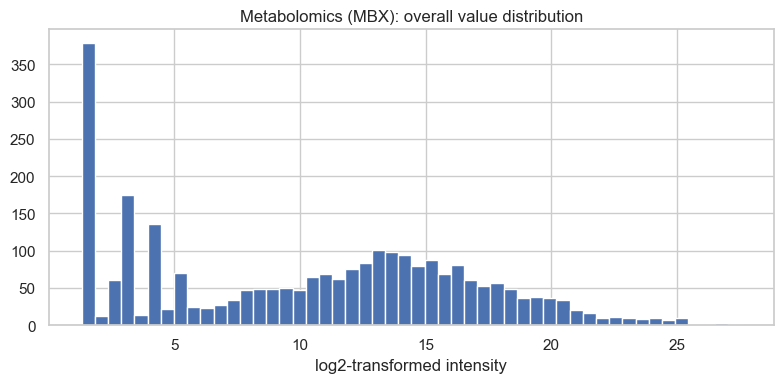

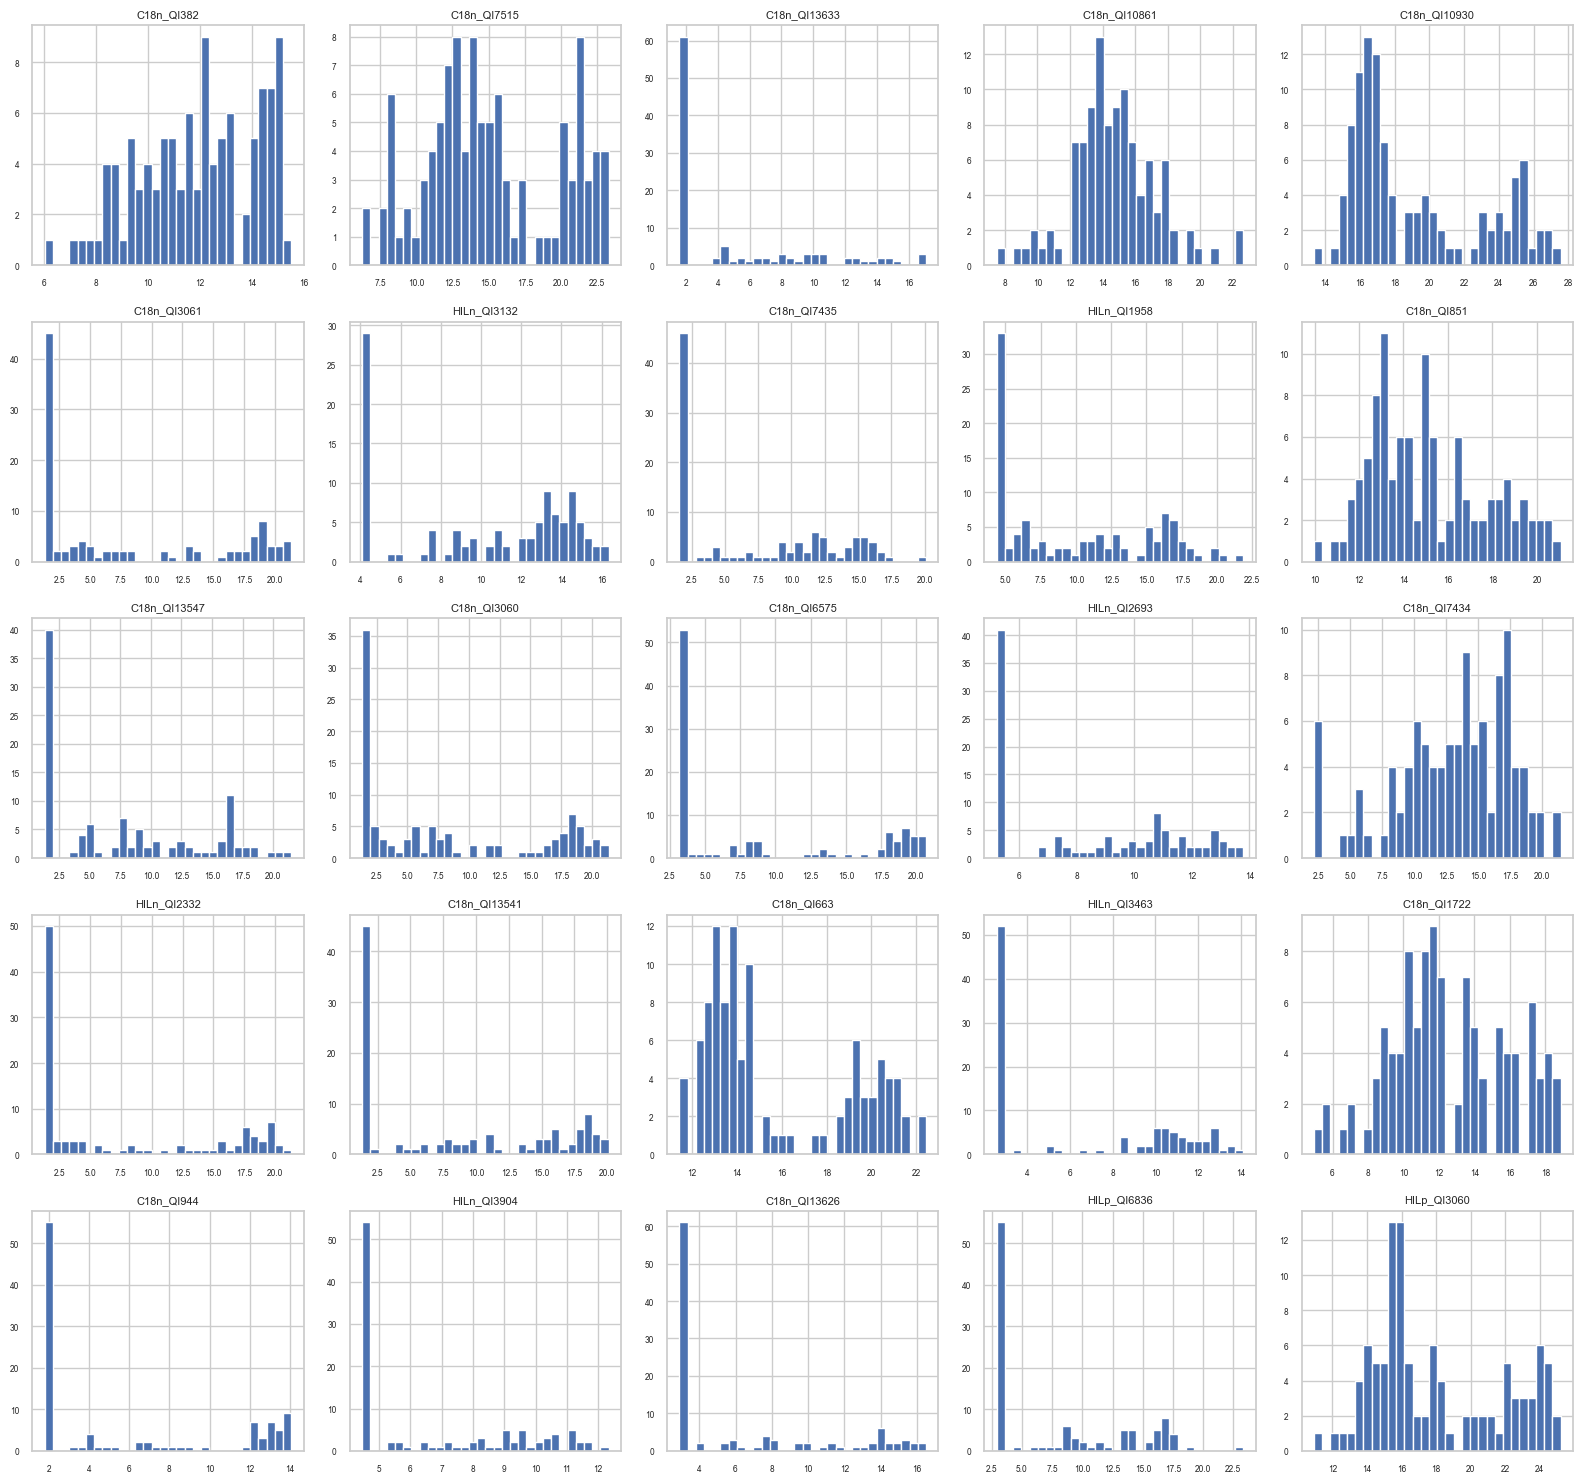

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mbx.values.flatten(), bins=50)
ax.set_title("Metabolomics (MBX): overall value distribution")
ax.set_xlabel("log2-transformed intensity")
plt.tight_layout()
plt.show()

n_feat = mbx.shape[1]
ncols = 5
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
for ax, col in zip(np.array(axes).flat, mbx.columns):
    ax.hist(mbx[col], bins=30)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)
for ax in np.array(axes).flat[n_feat:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Scale.** Per-feature variance/range — relevant for whether standardisation is needed before Graphical LASSO.

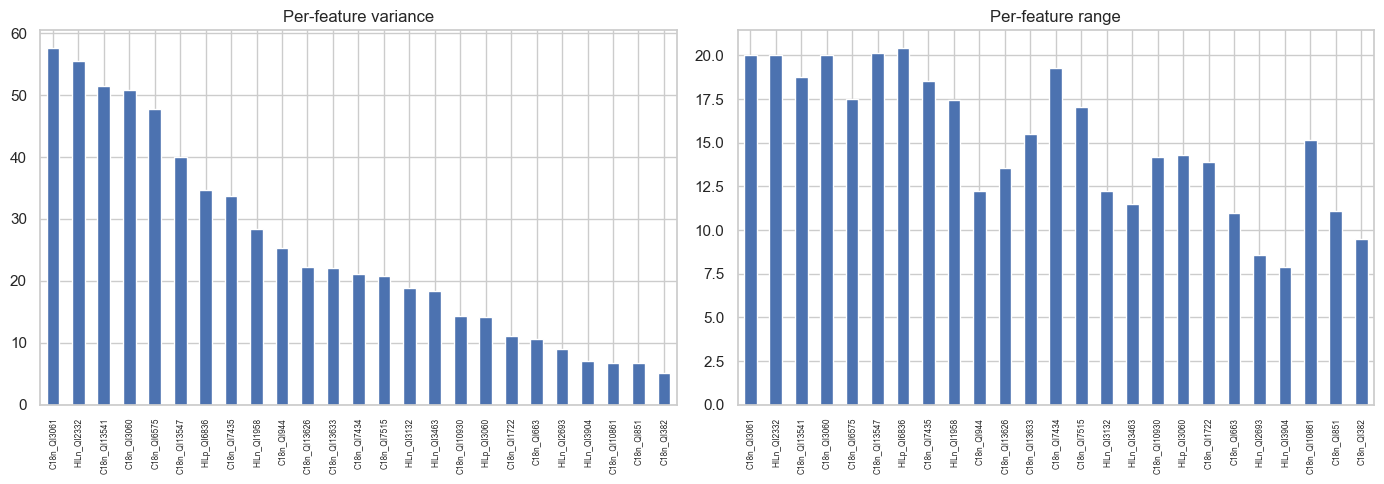

,variance,range
C18n_QI3061,57.589906,20.039394
HILn_QI2332,55.603346,20.013599
C18n_QI13541,51.461483,18.784139
C18n_QI3060,50.873927,20.031973
C18n_QI6575,47.847810,17.523561
C18n_QI13547,39.982837,20.163988
HILp_QI6836,34.730092,20.415587
C18n_QI7435,33.725136,18.523754
HILn_QI1958,28.318830,17.461287
C18n_QI944,25.307466,12.252750


In [17]:
scale_mbx = pd.DataFrame({
    "variance": mbx.var(),
    "range": mbx.max() - mbx.min(),
}).sort_values("variance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scale_mbx["variance"].plot(kind="bar", ax=axes[0], title="Per-feature variance")
scale_mbx["range"].plot(kind="bar", ax=axes[1], title="Per-feature range")
for ax in axes:
    ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

scale_mbx

**Normality.** Per-feature skewness/kurtosis, Q-Q plots for a representative subset, and Shapiro-Wilk results, cross-tabulated against the zero-inflation rate above.

Features rejecting normality (Shapiro, alpha=0.05): 24 / 25 (96.0%)


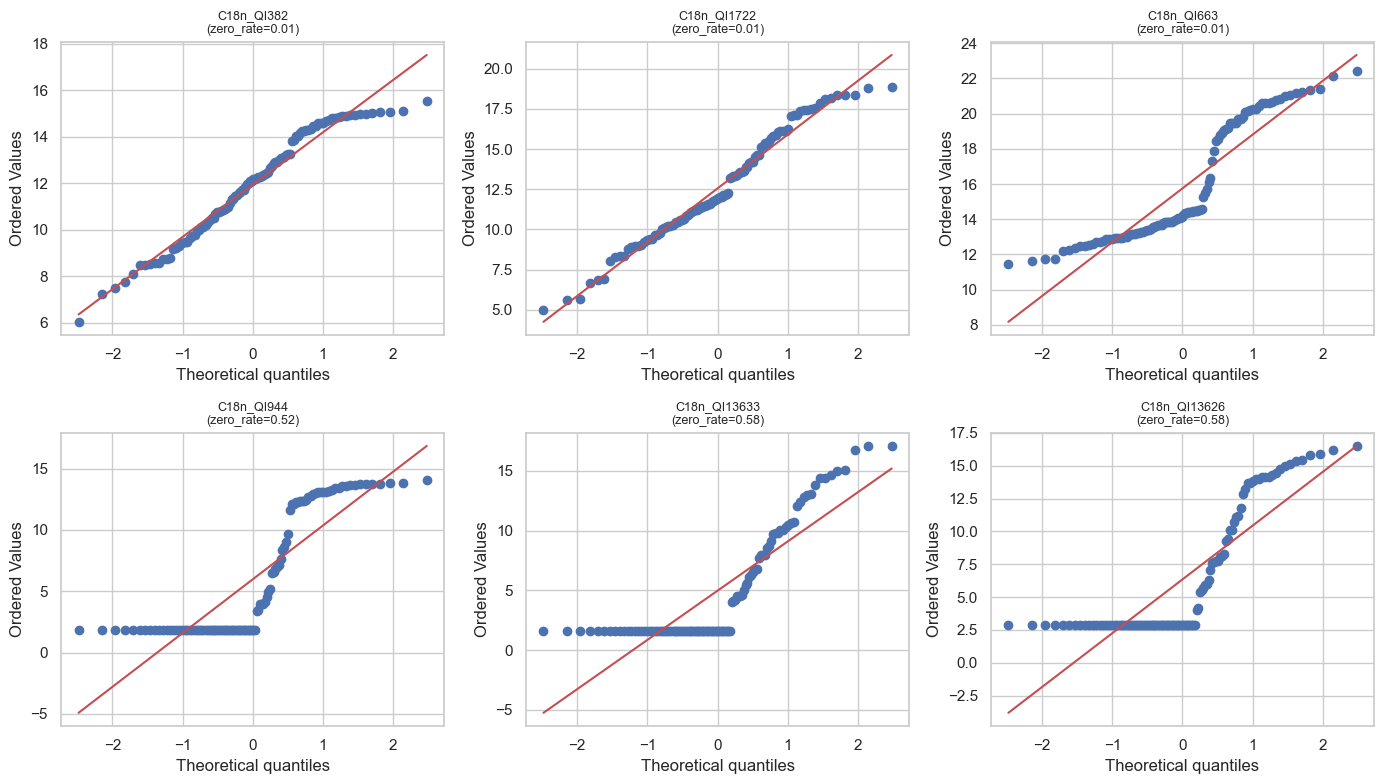

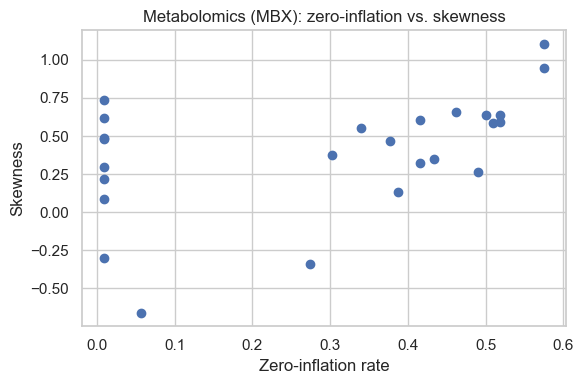

,skew,kurtosis,shapiro_p,reject_normal,zero_rate
feature,,,,,
C18n_QI13633,1.105351,-0.105486,2.261280e-12,True,0.575472
C18n_QI13626,0.947440,-0.738042,7.149686e-13,True,0.575472
C18n_QI944,0.591036,-1.459568,1.053277e-12,True,0.518868
HILp_QI6836,0.637901,-1.120900,2.625551e-11,True,0.518868
HILn_QI3904,0.582513,-1.291831,2.770217e-11,True,0.509434
C18n_QI6575,0.639848,-1.358119,2.525277e-12,True,0.500000
HILn_QI3463,0.264003,-1.707376,1.375244e-11,True,0.490566
HILn_QI2332,0.654607,-1.336341,3.924988e-12,True,0.462264
C18n_QI7435,0.351003,-1.435267,7.813239e-10,True,0.433962


In [18]:
norm_mbx = normality_summary(mbx).join(zero_rate_mbx.rename("zero_rate"))
print(f"Features rejecting normality (Shapiro, alpha=0.05): "
      f"{norm_mbx['reject_normal'].sum()} / {len(norm_mbx)} "
      f"({norm_mbx['reject_normal'].mean():.1%})")

example_cols = (
    norm_mbx.sort_values("zero_rate").index[:3].tolist()
    + norm_mbx.sort_values("zero_rate").index[-3:].tolist()
)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, example_cols):
    stats.probplot(mbx[col], dist="norm", plot=ax)
    ax.set_title(f"{col}\n(zero_rate={norm_mbx.loc[col, 'zero_rate']:.2f})", fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(norm_mbx["zero_rate"], norm_mbx["skew"])
ax.set_xlabel("Zero-inflation rate")
ax.set_ylabel("Skewness")
ax.set_title("Metabolomics (MBX): zero-inflation vs. skewness")
plt.tight_layout()
plt.show()

norm_mbx.sort_values("zero_rate", ascending=False)

**Outliers.**

Per-feature outlier rate (|z| > 3):
C18n_QI10861    0.018868
C18n_QI382      0.000000
HILn_QI2693     0.000000
HILp_QI6836     0.000000
C18n_QI13626    0.000000
HILn_QI3904     0.000000
C18n_QI944      0.000000
C18n_QI1722     0.000000
HILn_QI3463     0.000000
C18n_QI663      0.000000
C18n_QI13541    0.000000
HILn_QI2332     0.000000
C18n_QI7434     0.000000
C18n_QI6575     0.000000
C18n_QI7515     0.000000
C18n_QI3060     0.000000
C18n_QI13547    0.000000
C18n_QI851      0.000000
HILn_QI1958     0.000000
C18n_QI7435     0.000000
HILn_QI3132     0.000000
C18n_QI3061     0.000000
C18n_QI10930    0.000000
C18n_QI13633    0.000000
HILp_QI3060     0.000000
dtype: float64


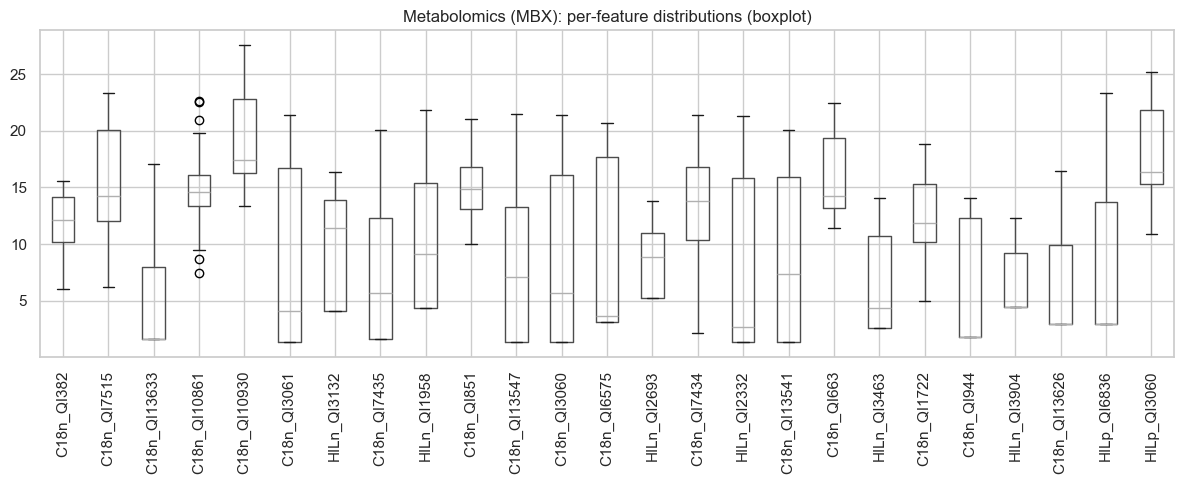

In [19]:
z_mbx = (mbx - mbx.mean()) / mbx.std()
outlier_rate_mbx = (z_mbx.abs() > 3).mean().sort_values(ascending=False)
print("Per-feature outlier rate (|z| > 3):")
print(outlier_rate_mbx)

fig, ax = plt.subplots(figsize=(12, 5))
mbx.boxplot(ax=ax, rot=90)
ax.set_title("Metabolomics (MBX): per-feature distributions (boxplot)")
plt.tight_layout()
plt.show()

### 2.3 Correlation structure\n\nPearson vs. Spearman correlation heatmaps side by side — large divergence between the two indicates non-linear/non-Gaussian relationships.

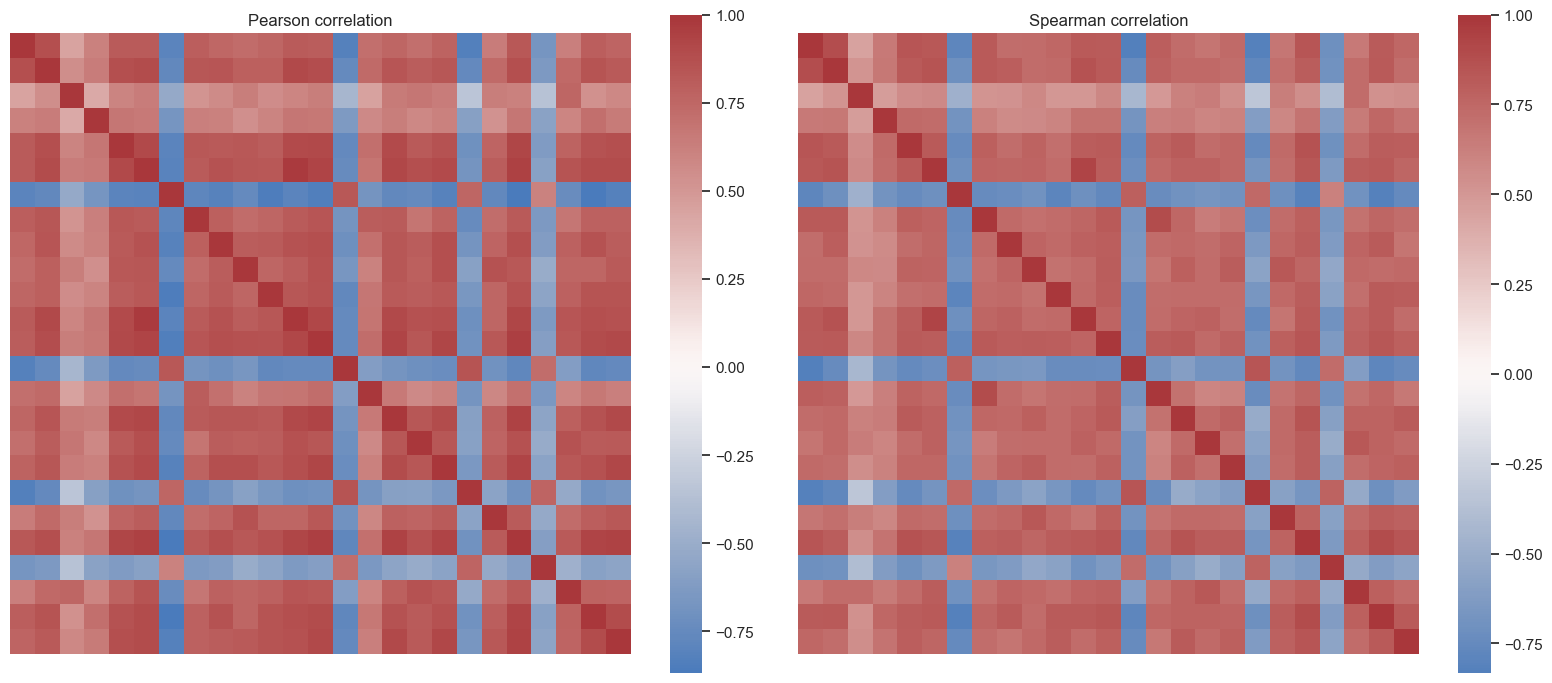

Mean |Pearson - Spearman| difference: 0.04963496973652241


In [20]:
pearson_mbx = mbx.corr(method="pearson")
spearman_mbx = mbx.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(pearson_mbx, ax=axes[0], cmap="vlag", center=0, square=True,
            xticklabels=False, yticklabels=False)
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman_mbx, ax=axes[1], cmap="vlag", center=0, square=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

print("Mean |Pearson - Spearman| difference:",
      (pearson_mbx - spearman_mbx).abs().values.mean())

### 2.4 Sample-level structure (PCA)\n\nPCA on the standardised feature table, coloured by diagnosis, to check for batch effects or cohort separation.

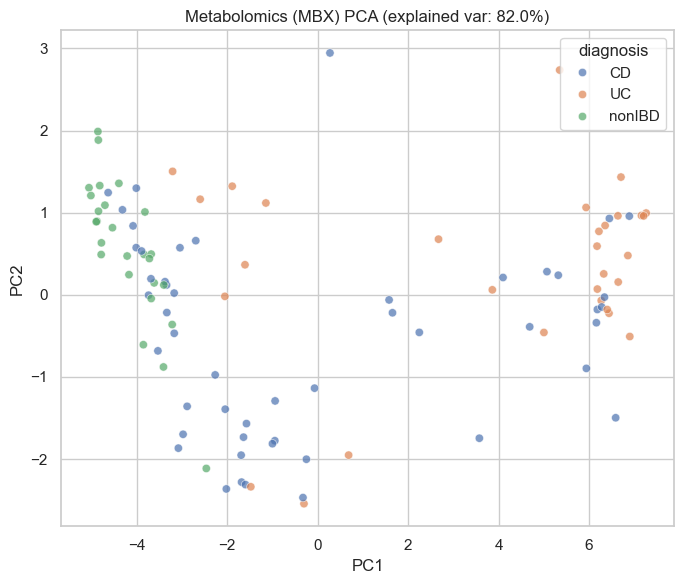

In [21]:
pca_mbx = PCA(n_components=2, random_state=0)
scores_mbx = pca_mbx.fit_transform(StandardScaler().fit_transform(mbx))
pca_mbx_df = pd.DataFrame(scores_mbx, columns=["PC1", "PC2"], index=mbx.index).join(mbx_meta)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_mbx_df, x="PC1", y="PC2", hue="diagnosis", ax=ax, alpha=0.7)
ax.set_title(f"Metabolomics (MBX) PCA (explained var: {pca_mbx.explained_variance_ratio_[:2].sum():.1%})")
plt.tight_layout()
plt.show()

### 2.5 Summary

The 25 log2-transformed metabolites retained by differential-abundance selection have no missing values. Detecting each metabolite's imputation floor directly (rather than checking for literal zeros, which no longer exist after below-detection-limit imputation and log-transformation) shows a mean floor rate of 28.9%, ranging from 0.9% (C18n_QI382) to 57.5% (C18n_QI13633). Shapiro-Wilk rejects normality for 24 of 25 features (96.0%), and the floor rate correlates moderately with skewness (r = 0.47) — a weaker relationship than for MGX, but in the same direction. Per-feature variance is moderately heterogeneous (coefficient of variation ≈ 0.66), similar to MGX. As with MGX, a nonparanormal transform on top of the existing log2 transform is recommended before Graphical LASSO (see Section 4).

## 3. Host transcriptomics (HTX)

Source: `Data/rna_transcriptomics_vst_processed.csv` — the differentially expressed genes selected in `pipeline.ipynb` (DESeq2 Wald tests, CD vs. non-IBD and UC vs. non-IBD), already size-factor normalised and variance-stabilised (VST), aggregated to one baseline sample per participant. Earlier versions of this notebook independently re-derived HTX from raw counts using a different pipeline (CPM + log2, a 50%-expression filter, no differential-expression selection) — that no longer matches what `pipeline.ipynb` actually feeds into the network, so this section now loads the same file the other two layers load: the final per-layer output.

### 3.1 Load data and align with metadata

In [22]:
rnaseq = pd.read_csv(f"{DATA_DIR}/rna_transcriptomics_vst_processed.csv", index_col=0)
rnaseq.index.name = "Participant ID"

rnaseq_meta = participant_meta.reindex(rnaseq.index)
print(f"HTX participants: {rnaseq.shape[0]}, matched metadata: {rnaseq_meta['diagnosis'].notna().sum()}")
rnaseq_meta.head()

HTX participants: 90, matched metadata: 90


,diagnosis,site_name
Participant ID,,
C3002,CD,Cedars-Sinai
C3003,UC,Cedars-Sinai
C3004,UC,Cedars-Sinai
C3005,UC,Cedars-Sinai
C3006,UC,Cedars-Sinai


### 3.2 Distributional diagnostics

**Shape and structure.**

In [23]:
print("Shape:", rnaseq.shape)
print(rnaseq.dtypes.value_counts())
rnaseq.head()

Shape: (90, 25)
float64    25
Name: count, dtype: int64


,C4BPB,CXCR1,TCN1,FPR2,MMP3,C2CD4A,MMP10,CXCL5,AQP9,SAA1,...,ITLN2,FCGR3B,REG1A,DUOXA2,TNIP3,CHI3L1,CXCL11,ABCA12,SAA2,IL11
Participant ID,,,,,,,,,,,,,,,,,,,,,
C3002,7.967006,5.000949,4.963625,5.141264,8.454164,7.748699,7.241643,11.325251,5.667440,9.779016,...,9.565367,6.829729,11.441710,11.333040,9.384943,10.786231,9.097088,6.235394,7.233832,3.721467
C3003,6.214621,1.602633,1.602633,1.127114,5.205638,4.841895,2.432020,5.344812,2.432020,1.941360,...,3.314472,3.077174,7.137066,6.466971,5.632492,3.077174,3.996018,3.517704,-0.141088,1.602633
C3004,7.271794,3.071180,6.278157,4.589491,9.611339,7.840643,6.780592,4.589491,4.293406,3.689062,...,11.437335,4.449057,11.557461,5.846474,4.589491,8.543182,5.954183,2.617980,-0.141088,3.689062
C3005,8.295640,2.682361,2.962380,2.113881,6.561422,6.727142,4.169693,5.309646,2.962380,3.799758,...,5.787111,3.799758,7.062524,8.892275,4.669528,6.443062,7.657990,6.030451,1.526380,2.113881
C3006,10.875989,10.874277,9.719721,11.352268,12.508861,8.468099,9.601851,12.019155,12.169414,11.284244,...,11.181340,11.713567,15.446109,12.991844,10.855879,13.117579,11.678337,10.954819,8.527425,9.696646


**Missingness and zero-inflation.**\n\nQuantify the proportion of participants at exactly zero VST-transformed expression per gene.

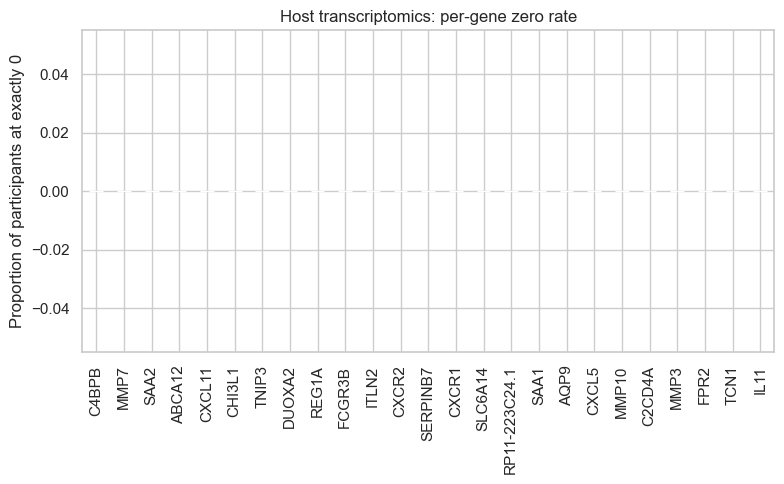

Max NaNs in any feature: 0


,zero_rate
C4BPB,0.0
MMP7,0.0
SAA2,0.0
ABCA12,0.0
CXCL11,0.0
CHI3L1,0.0
TNIP3,0.0
DUOXA2,0.0
REG1A,0.0
FCGR3B,0.0


In [24]:
# VST output does not have a floor artefact the way CLR/log-imputation do, so
# this simply checks for exact zeros left over from the transform.
zero_rate_rnaseq = (rnaseq == 0).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
zero_rate_rnaseq.plot(kind="bar", ax=ax)
ax.set_ylabel("Proportion of participants at exactly 0")
ax.set_title("Host transcriptomics: per-gene zero rate")
plt.tight_layout()
plt.show()

print("Max NaNs in any feature:", rnaseq.isna().sum().max())
zero_rate_rnaseq.to_frame("zero_rate")

**Summary statistics.**

In [25]:
rnaseq.describe().T

,count,mean,std,min,25%,50%,75%,max
C4BPB,90.0,7.019338,2.242497,-0.141088,5.226638,6.263657,8.731075,11.665325
CXCR1,90.0,4.114594,3.165920,-0.141088,1.948302,2.755528,6.681333,11.977713
TCN1,90.0,4.139404,3.026779,-0.141088,2.068081,3.068437,6.243258,12.028830
FPR2,90.0,4.503949,3.022634,-0.141088,2.214785,3.393948,6.532945,12.839465
MMP3,90.0,7.517010,3.522893,-0.141088,5.034664,6.433425,10.058657,16.822087
C2CD4A,90.0,5.711402,2.052576,-0.141088,4.388996,5.078993,7.236369,9.710030
MMP10,90.0,4.807124,3.377606,-0.141088,1.971361,4.082268,7.524403,11.718076
CXCL5,90.0,6.855664,3.472110,-0.141088,4.274269,6.211321,9.833042,14.271858
AQP9,90.0,4.979291,3.491571,-0.141088,2.279333,3.977984,7.625498,15.309492
SAA1,90.0,5.234358,3.764396,-0.141088,2.238785,3.795893,8.530666,14.165666


**Distribution.**

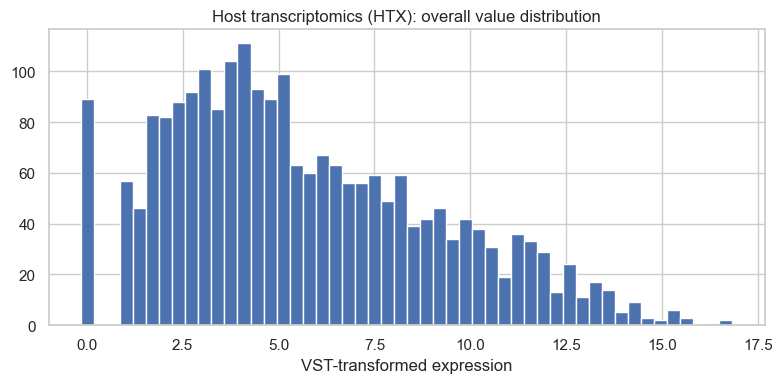

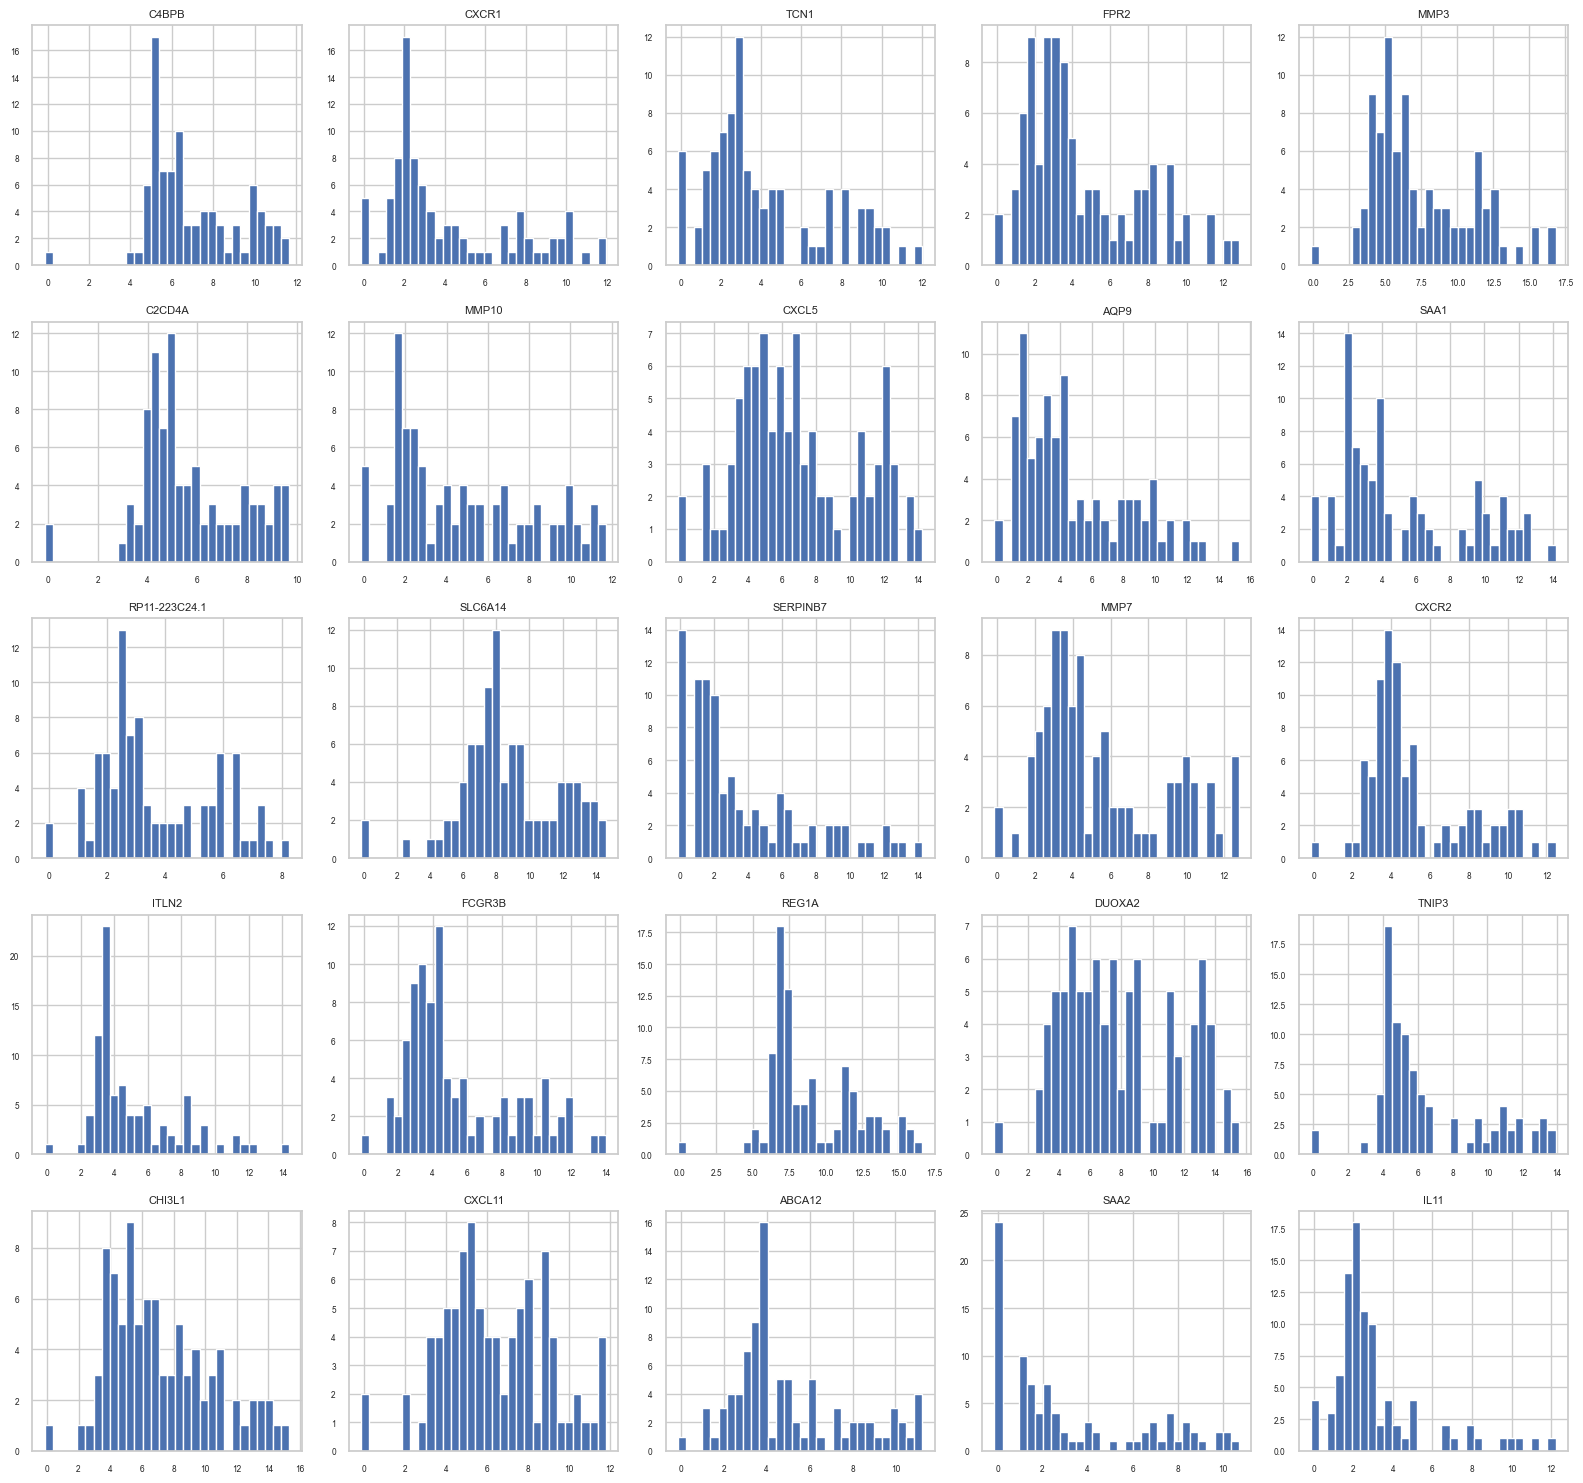

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rnaseq.values.flatten(), bins=50)
ax.set_title("Host transcriptomics (HTX): overall value distribution")
ax.set_xlabel("VST-transformed expression")
plt.tight_layout()
plt.show()

n_feat = rnaseq.shape[1]
ncols = 5
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
for ax, col in zip(np.array(axes).flat, rnaseq.columns):
    ax.hist(rnaseq[col], bins=30)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)
for ax in np.array(axes).flat[n_feat:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Scale.** Per-feature variance/range — relevant for whether standardisation is needed before Graphical LASSO.

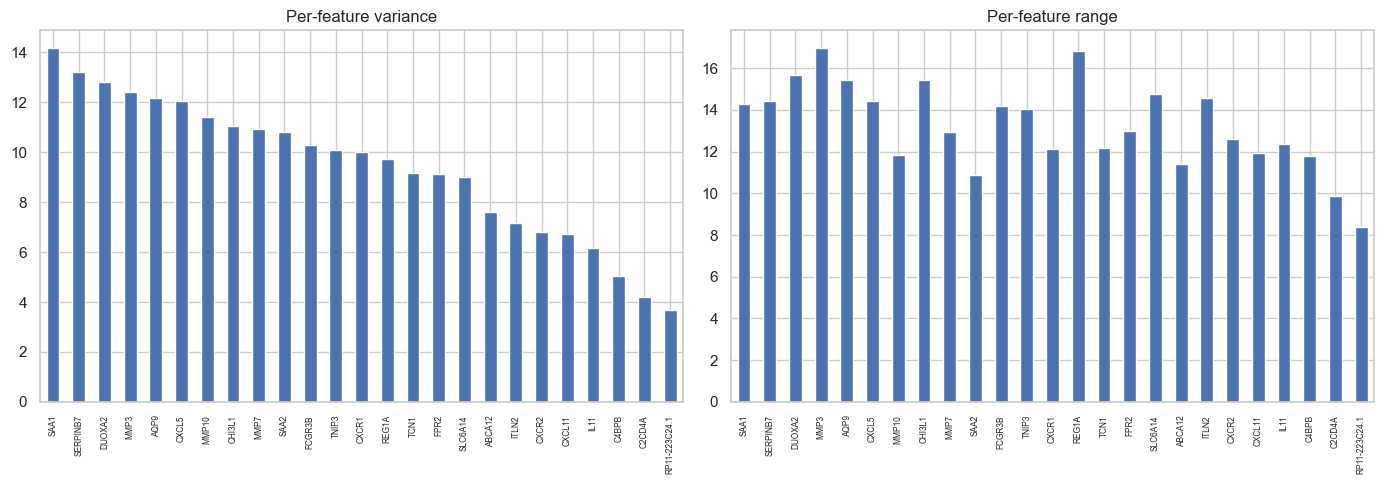

,variance,range
SAA1,14.170677,14.306754
SERPINB7,13.202188,14.406442
DUOXA2,12.809898,15.679369
MMP3,12.410777,16.963175
AQP9,12.191070,15.450580
CXCL5,12.055545,14.412946
MMP10,11.408224,11.859164
CHI3L1,11.039699,15.457515
MMP7,10.918315,12.928538
SAA2,10.797621,10.857929


In [27]:
scale_rnaseq = pd.DataFrame({
    "variance": rnaseq.var(),
    "range": rnaseq.max() - rnaseq.min(),
}).sort_values("variance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scale_rnaseq["variance"].plot(kind="bar", ax=axes[0], title="Per-feature variance")
scale_rnaseq["range"].plot(kind="bar", ax=axes[1], title="Per-feature range")
for ax in axes:
    ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

scale_rnaseq

**Normality.** Per-feature skewness/kurtosis, Q-Q plots for a representative subset, and Shapiro-Wilk results, cross-tabulated against the zero-inflation rate above.

Features rejecting normality (Shapiro, alpha=0.05): 24 / 25 (96.0%)


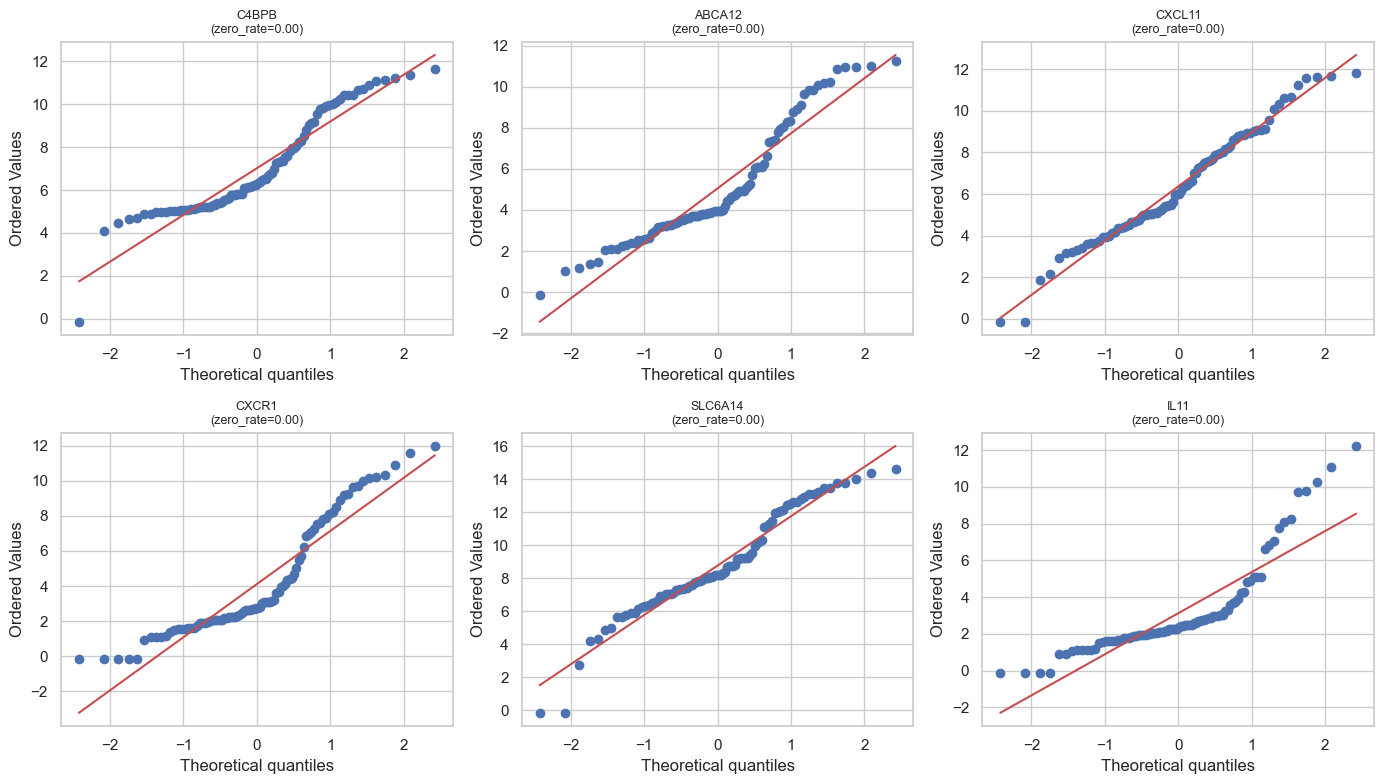

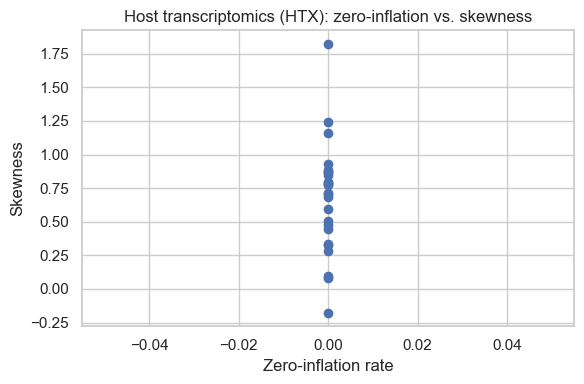

,skew,kurtosis,shapiro_p,reject_normal,zero_rate
feature,,,,,
C4BPB,0.284821,-0.083197,1.673085e-05,True,0.0
MMP7,0.708533,-0.606338,1.273150e-05,True,0.0
SAA2,0.799172,-0.711616,6.133413e-08,True,0.0
ABCA12,0.776528,-0.368897,1.062944e-05,True,0.0
CXCL11,0.093893,-0.275825,1.479502e-01,False,0.0
CHI3L1,0.592965,-0.345087,2.226515e-03,True,0.0
TNIP3,0.789014,-0.209490,1.501263e-07,True,0.0
DUOXA2,0.327415,-0.919418,1.895925e-03,True,0.0
REG1A,0.449168,-0.032184,3.035712e-05,True,0.0


In [28]:
norm_rnaseq = normality_summary(rnaseq).join(zero_rate_rnaseq.rename("zero_rate"))
print(f"Features rejecting normality (Shapiro, alpha=0.05): "
      f"{norm_rnaseq['reject_normal'].sum()} / {len(norm_rnaseq)} "
      f"({norm_rnaseq['reject_normal'].mean():.1%})")

example_cols = (
    norm_rnaseq.sort_values("zero_rate").index[:3].tolist()
    + norm_rnaseq.sort_values("zero_rate").index[-3:].tolist()
)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, example_cols):
    stats.probplot(rnaseq[col], dist="norm", plot=ax)
    ax.set_title(f"{col}\n(zero_rate={norm_rnaseq.loc[col, 'zero_rate']:.2f})", fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(norm_rnaseq["zero_rate"], norm_rnaseq["skew"])
ax.set_xlabel("Zero-inflation rate")
ax.set_ylabel("Skewness")
ax.set_title("Host transcriptomics (HTX): zero-inflation vs. skewness")
plt.tight_layout()
plt.show()

norm_rnaseq.sort_values("zero_rate", ascending=False)

**Outliers.**

Per-feature outlier rate (|z| > 3):
IL11             0.022222
ITLN2            0.011111
C4BPB            0.011111
FPR2             0.000000
MMP3             0.000000
SAA2             0.000000
ABCA12           0.000000
CXCL11           0.000000
CHI3L1           0.000000
TNIP3            0.000000
DUOXA2           0.000000
REG1A            0.000000
FCGR3B           0.000000
TCN1             0.000000
CXCR2            0.000000
MMP7             0.000000
CXCR1            0.000000
SLC6A14          0.000000
RP11-223C24.1    0.000000
SAA1             0.000000
AQP9             0.000000
CXCL5            0.000000
MMP10            0.000000
C2CD4A           0.000000
SERPINB7         0.000000
dtype: float64


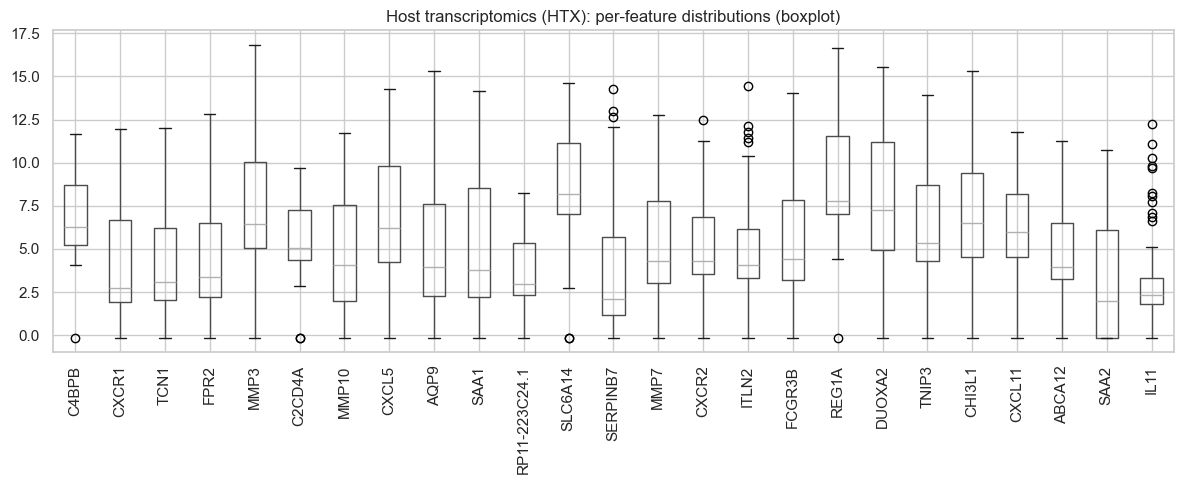

In [29]:
z_rnaseq = (rnaseq - rnaseq.mean()) / rnaseq.std()
outlier_rate_rnaseq = (z_rnaseq.abs() > 3).mean().sort_values(ascending=False)
print("Per-feature outlier rate (|z| > 3):")
print(outlier_rate_rnaseq)

fig, ax = plt.subplots(figsize=(12, 5))
rnaseq.boxplot(ax=ax, rot=90)
ax.set_title("Host transcriptomics (HTX): per-feature distributions (boxplot)")
plt.tight_layout()
plt.show()

### 3.3 Correlation structure\n\nPearson vs. Spearman correlation heatmaps side by side — large divergence between the two indicates non-linear/non-Gaussian relationships.

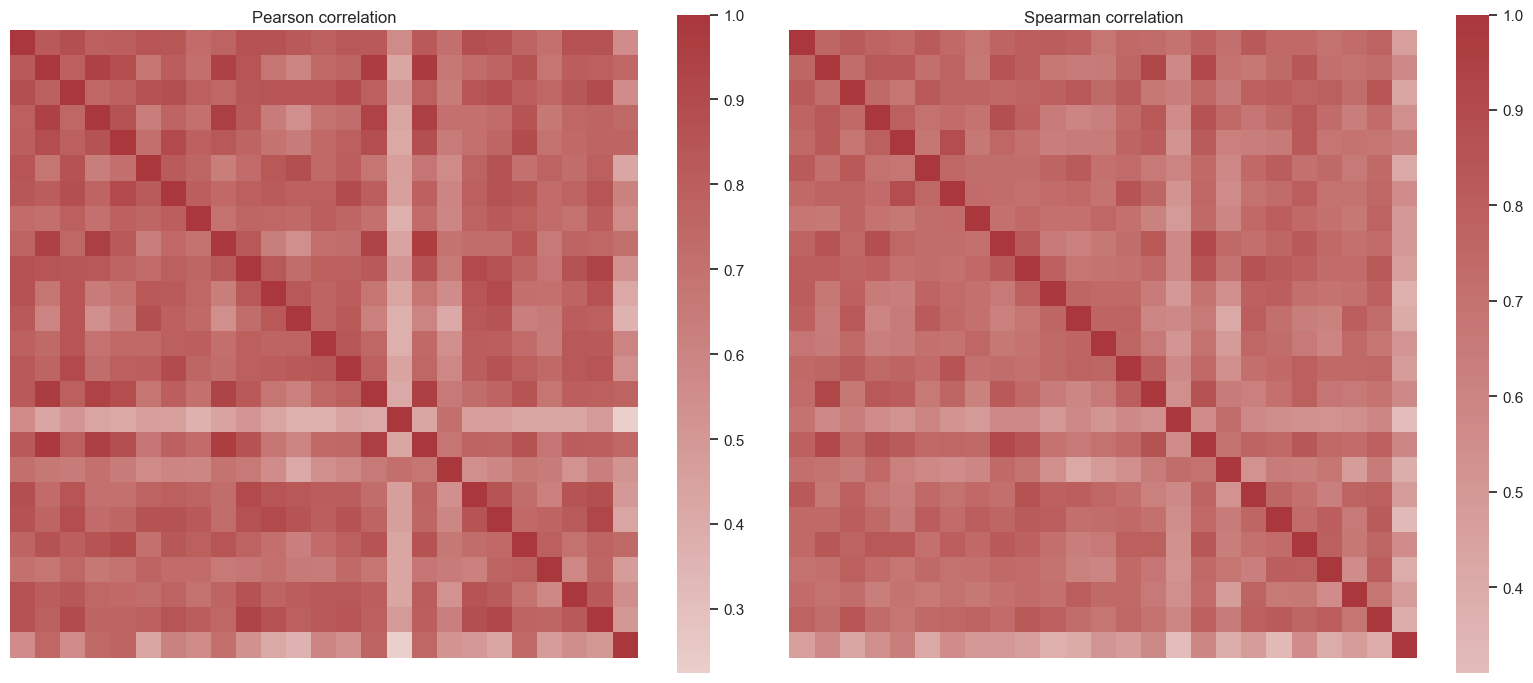

Mean |Pearson - Spearman| difference: 0.058950214199933064


In [30]:
pearson_rnaseq = rnaseq.corr(method="pearson")
spearman_rnaseq = rnaseq.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(pearson_rnaseq, ax=axes[0], cmap="vlag", center=0, square=True,
            xticklabels=False, yticklabels=False)
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman_rnaseq, ax=axes[1], cmap="vlag", center=0, square=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

print("Mean |Pearson - Spearman| difference:",
      (pearson_rnaseq - spearman_rnaseq).abs().values.mean())

### 3.4 Sample-level structure (PCA)\n\nPCA on the standardised feature table, coloured by diagnosis, to check for batch effects or cohort separation.

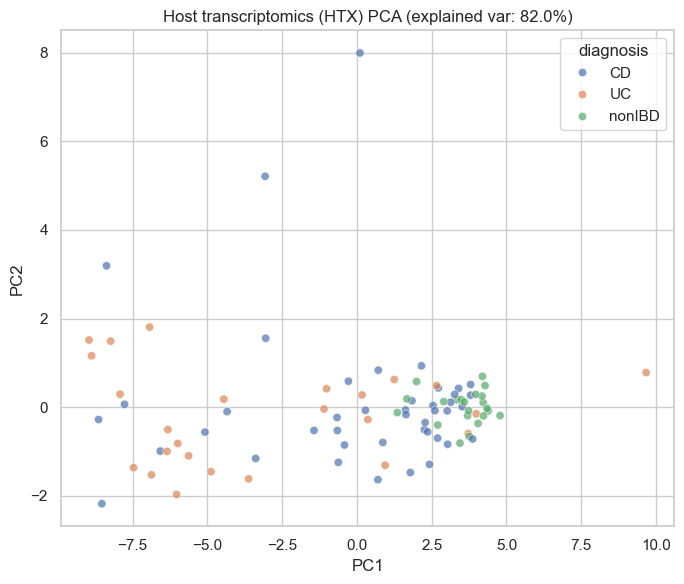

In [31]:
pca_rnaseq = PCA(n_components=2, random_state=0)
scores_rnaseq = pca_rnaseq.fit_transform(StandardScaler().fit_transform(rnaseq))
pca_rnaseq_df = pd.DataFrame(scores_rnaseq, columns=["PC1", "PC2"], index=rnaseq.index).join(rnaseq_meta)

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_rnaseq_df, x="PC1", y="PC2", hue="diagnosis", ax=ax, alpha=0.7)
ax.set_title(f"Host transcriptomics (HTX) PCA (explained var: {pca_rnaseq.explained_variance_ratio_[:2].sum():.1%})")
plt.tight_layout()
plt.show()

### 3.5 Summary

The 25 genes selected by DESeq2 Wald tests (CD vs. non-IBD, UC vs. non-IBD), already size-factor normalised and variance-stabilised (VST), have no missing values and no exact-zero point mass — VST stabilises variance without leaving a floor artefact the way CLR or log-imputation do. Shapiro-Wilk still rejects normality for 24 of 25 genes (96.0%), indicating VST alone does not fully normalise even this small, already differentially-expressed gene set. Per-feature variance is the most homogeneous of the three layers (coefficient of variation ≈ 0.30) — lower than both MGX and metabolomics — consistent with VST's explicit variance-stabilisation objective, so standardisation matters less here than for the other two layers, though it is still applied for consistency across the joint matrix. As with the other layers, a nonparanormal transform on top of VST is recommended before Graphical LASSO (see Section 4).

This reflects the actual 25-gene, pipeline-selected input to the network (rank-and-cap selection, NODE_BUDGET=25, as of the 2026-08-13 pipeline rerun). An earlier version of this section instead independently re-derived HTX from raw counts using a different pipeline (CPM + log2, a 50%-expression filter, no differential-expression selection), which described a 27,353-gene set that was never actually used downstream; that analysis has been replaced with this one.

## 4. Cross-layer synthesis: normality, scale, and implications for Graphical LASSO

In [32]:
summary_table = pd.DataFrame({
    "n_participants": [mgx.shape[0], mbx.shape[0], rnaseq.shape[0]],
    "n_features": [mgx.shape[1], mbx.shape[1], rnaseq.shape[1]],
    "pct_reject_normality": [
        norm_mgx["reject_normal"].mean(),
        norm_mbx["reject_normal"].mean(),
        norm_rnaseq["reject_normal"].mean(),
    ],
    "mean_zero_rate": [
        zero_rate_mgx.mean(),
        zero_rate_mbx.mean(),
        zero_rate_rnaseq.mean(),
    ],
    "variance_cv": [  # coefficient of variation of per-feature variance: scale homogeneity
        mgx.var().std() / mgx.var().mean(),
        mbx.var().std() / mbx.var().mean(),
        rnaseq.var().std() / rnaseq.var().mean(),
    ],
}, index=["MGX", "Metabolomics", "Host transcriptomics"])

summary_table

,n_participants,n_features,pct_reject_normality,mean_zero_rate,variance_cv
MGX,130,25,1.00,0.356308,0.504830
Metabolomics,106,25,0.96,0.289057,0.658528
Host transcriptomics,90,25,0.96,0.000000,0.303708


**Normality and Graphical LASSO.** Graphical LASSO estimates a sparse precision matrix under a Gaussian Graphical Model: zero entries are interpreted as conditional independencies because the joint distribution is assumed multivariate normal. The per-layer transforms already applied (CLR for MGX, log2 for metabolomics, VST for host transcriptomics) address compositionality, skew, and the count-based nature of the data respectively, but the zero/floor point masses identified above still violate per-feature normality, as quantified in the table above.

The standard remedy is a nonparanormal / Gaussian copula transform — a rank-based marginal transform to normal quantiles, e.g. `huge::huge.npn` in R or `sklearn.preprocessing.QuantileTransformer(output_distribution="normal")` in Python — applied on top of the existing layer-specific transforms. This relaxes the requirement from "each variable is Gaussian" to "each variable is a monotone transform of a Gaussian", which is what Graphical LASSO needs for its conditional-independence interpretation to hold.

**Scale.** Graphical LASSO's L1 penalty is applied uniformly across the precision matrix, so all features should be on comparable variance scales, or the model should be fit on the correlation rather than covariance matrix. The `variance_cv` column above quantifies how homogeneous per-feature variances are within each layer; a high value indicates standardisation is required in addition to the nonparanormal transform.

**Observed values.** All three layers reject normality for the large majority of features: 100% for MGX, and 96% for both metabolomics and host transcriptomics, indicating that CLR, log2, and VST each substantially reduce but do not eliminate the zero/floor-driven non-normality documented above. Variance heterogeneity (`variance_cv`) is broadly comparable for MGX (0.50) and metabolomics (0.66), and lowest for host transcriptomics (0.30), reflecting VST's explicit variance-stabilisation objective. Standardisation before Graphical LASSO is therefore beneficial across all three layers, and most clearly warranted for metabolomics.

**Recommendation.** Apply a uniform nonparanormal transform (with standardisation) as the final preprocessing step across all three layers before joint / prior-informed Graphical LASSO.

## 5. Cross-layer participant overlap

This section quantifies how many participants have data in more than one omics layer. This matters for joint network inference: Graphical LASSO across layers requires a shared set of participants present in all three tables. Since all three layers loaded above are already aggregated to one row per `Participant ID` (median/VST aggregation collapses the original per-visit timepoints), overlap is computed directly on participant identity — there is no separate sample-vs-participant distinction left to make, and no timepoint-level granularity survives the per-layer aggregation to check a same-visit overlap against.

### 5.1 Raw sample availability vs. mapped participants

MGX's participant count (130, Section 5.2 below) is smaller than its raw sample count (1,638 stool specimens processed for MGX) because most samples map many-to-one onto participants under HMP2's repeated home stool-collection design, not because of missing data. This subsection documents that mapping step directly on the raw file, both as a sanity check and as a record of a pipeline bug it previously caused: the External ID suffix-stripping regex initially matched only `_P_profile`/`_P`, missing the bare `_profile` suffix used by 1,338 of the 1,638 raw MGX sample columns, which silently left those samples unmapped and undercounted MGX participants at 117 instead of 130. The regex was corrected in `pipeline.ipynb` (`_P_profile$|_profile$|_P$`) before this analysis; the comparison below re-derives both the broken and fixed outcome directly from the raw data for verification.

In [33]:
# Re-derive the raw MGX sample -> participant mapping directly from source files,
# to document the suffix-stripping bug and confirm the fix independently of pipeline.ipynb.
mgx_raw_path = f"{DATA_DIR}/Unprocessed_Other/mgx_species_abundances_raw.tsv"
mgx_raw = pd.read_csv(mgx_raw_path, sep="\t", index_col=0)

species_mask = mgx_raw.index.str.contains(r"\|s__", regex=True)
raw_sample_ids = mgx_raw.loc[species_mask].T.index
n_raw_samples = len(raw_sample_ids)

eid_to_pid = metadata.drop_duplicates("External ID").set_index("External ID")["Participant ID"]

regex_variants = {
    "Broken (pre-fix): _P_profile$|_P$": r"_P_profile$|_P$",
    "Fixed: _P_profile$|_profile$|_P$": r"_P_profile$|_profile$|_P$",
}

mapping_rows = []
for label, pattern in regex_variants.items():
    cleaned = raw_sample_ids.str.replace(pattern, "", regex=True)
    mapped_pid = cleaned.map(
        metadata.assign(eid_clean=metadata["External ID"].str.replace(pattern, "", regex=True))
        .drop_duplicates("eid_clean")
        .set_index("eid_clean")["Participant ID"]
    )
    n_mapped_samples = mapped_pid.notna().sum()
    n_participants = mapped_pid.dropna().nunique()
    mapping_rows.append({
        "regex": label,
        "raw_samples": n_raw_samples,
        "mapped_samples": n_mapped_samples,
        "unmapped_samples": n_raw_samples - n_mapped_samples,
        "participants_recovered": n_participants,
    })

mapping_summary = pd.DataFrame(mapping_rows).set_index("regex")
mapping_summary


,raw_samples,mapped_samples,unmapped_samples,participants_recovered
regex,,,,
Broken (pre-fix): _P_profile$|_P$,1638,300,1338,117
Fixed: _P_profile$|_profile$|_P$,1638,1638,0,130


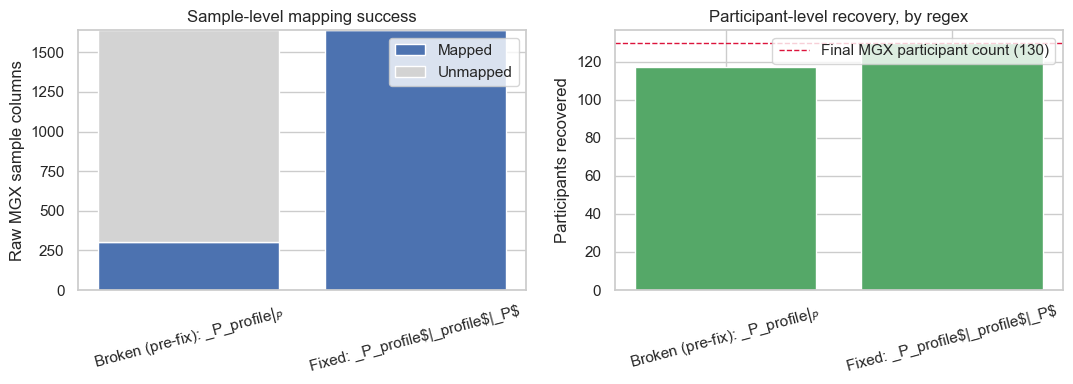

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(mapping_summary.index, mapping_summary["mapped_samples"], color="C0", label="Mapped")
axes[0].bar(mapping_summary.index, mapping_summary["unmapped_samples"],
            bottom=mapping_summary["mapped_samples"], color="lightgray", label="Unmapped")
axes[0].set_ylabel("Raw MGX sample columns")
axes[0].set_title("Sample-level mapping success")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

axes[1].bar(mapping_summary.index, mapping_summary["participants_recovered"], color="C2")
axes[1].axhline(130, color="crimson", linestyle="--", linewidth=1, label="Final MGX participant count (130)")
axes[1].set_ylabel("Participants recovered")
axes[1].set_title("Participant-level recovery, by regex")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()


The broken regex left 1,338 of 1,638 raw MGX sample columns unmapped (any bare `_profile`-suffixed ID), because most samples never carry the `_P` immediately before `_profile`. Despite this, repeated stool sampling meant enough participants still had at least one successfully-mapped sample to reach 117 participants rather than a more severe drop — the bug degraded participant count rather than eliminating the layer outright, which is why it was not immediately obvious from participant counts alone. The fixed regex maps all 1,638 samples and recovers the full 130 participants confirmed elsewhere in this notebook (Section 5.2) and in `pipeline.ipynb`.

### 5.2 Participant overlap across layers

In [35]:
mgx_pid = set(mgx.index)
mbx_pid = set(mbx.index)
rna_pid = set(rnaseq.index)

print(f"MGX: {len(mgx_pid)} participants")
print(f"Metabolomics: {len(mbx_pid)} participants")
print(f"Host transcriptomics: {len(rna_pid)} participants")

labels = ["MGX", "Metabolomics", "Host transcriptomics"]
sets = [mgx_pid, mbx_pid, rna_pid]
pairs = [(0, 1), (0, 2), (1, 2)]

overlap_summary = pd.Series({
    **{f"{labels[i]} & {labels[j]}": len(sets[i] & sets[j]) for i, j in pairs},
    "All three": len(sets[0] & sets[1] & sets[2]),
})
overlap_summary.to_frame("n_participants")

MGX: 130 participants
Metabolomics: 106 participants
Host transcriptomics: 90 participants


,n_participants
MGX & Metabolomics,106
MGX & Host transcriptomics,90
Metabolomics & Host transcriptomics,90
All three,90


### 5.3 Venn diagram

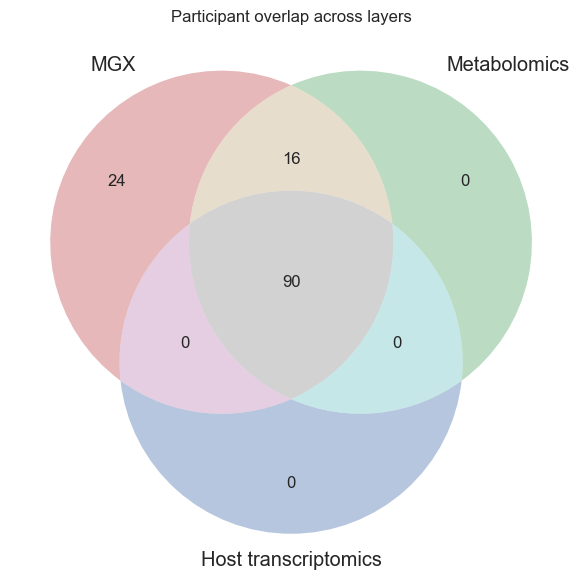

In [36]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

fig, ax = plt.subplots(figsize=(7, 6))
venn3([mgx_pid, mbx_pid, rna_pid], set_labels=("MGX", "Metabolomics", "Host transcriptomics"), ax=ax,
      layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1)))
ax.set_title("Participant overlap across layers")
plt.tight_layout()
plt.show()

### 5.4 Summary

## 6. Selection-bias check: DA/DE-selected features vs. full candidate pool

This section evaluates whether the DA/DE-selected features already analysed above (Sections 1-3) are systematically more extreme than a typical feature in the full prevalence-filtered candidate pool each layer was selected from. Graphical LASSO assumes an approximately Gaussian input; if differential-abundance/expression selection preferentially retains the most skewed or zero-inflated candidates, that would compound the non-normality already characterised above beyond what a similarly-sized random draw from the same pool would show. Candidate pools are read from the full prevalence-filtered matrices saved directly from `pipeline.ipynb`, before any DA/DE selection is applied (`Data/mgx_species_clr_full_pool.csv`, `Data/mbx_metabolomics_log_full_pool.csv`, `Data/rna_transcriptomics_vst_full_pool.csv`). Per-feature skewness and the layer-appropriate zero/floor rate are compared between the pool and the selected subset, using the same zero-inflation definitions as Sections 1-3.

In [37]:
# For each layer, compare the DA/DE-selected features already loaded above
# (norm_mgx, norm_mbx, norm_rnaseq) against the full prevalence-filtered candidate
# pool they were selected from. Per-feature skewness/zero-rate on the full pool
# only (no per-feature Shapiro-Wilk, which would be too slow across tens of
# thousands of candidates) is enough to check whether selection systematically
# favours more extreme (skewed / zero-inflated) features than a typical candidate.
pool_paths = {
    "MGX": f"{DATA_DIR}/mgx_species_clr_full_pool.csv",
    "Metabolomics": f"{DATA_DIR}/mbx_metabolomics_log_full_pool.csv",
    "Host transcriptomics": f"{DATA_DIR}/rna_transcriptomics_vst_full_pool.csv",
}
selected_norm = {"MGX": norm_mgx, "Metabolomics": norm_mbx, "Host transcriptomics": norm_rnaseq}

bias_rows = []
pool_skew = {}

for layer, path in pool_paths.items():
    pool = pd.read_csv(path, index_col=0)

    skew_full = pd.Series(stats.skew(pool.values, axis=0, nan_policy="omit"), index=pool.columns)
    pool_skew[layer] = skew_full

    # Zero-inflation definition matches the one already used for this layer above.
    if layer == "MGX":
        row_floor = pool.min(axis=1)
        zero_full = pool.eq(row_floor, axis=0).mean(axis=0)
    elif layer == "Metabolomics":
        col_floor = pool.min(axis=0)
        zero_full = pool.eq(col_floor, axis=1).mean(axis=0)
    else:
        zero_full = (pool == 0).mean(axis=0)

    sel_skew = selected_norm[layer]["skew"]
    sel_zero = selected_norm[layer]["zero_rate"]

    bias_rows.append({
        "layer": layer,
        "n_candidates": pool.shape[1],
        "n_selected": len(sel_skew),
        "pool_mean_abs_skew": skew_full.abs().mean(),
        "selected_mean_abs_skew": sel_skew.abs().mean(),
        "selected_abs_skew_percentile": stats.percentileofscore(skew_full.abs(), sel_skew.abs().mean()),
        "pool_mean_zero_rate": zero_full.mean(),
        "selected_mean_zero_rate": sel_zero.mean(),
        "selected_zero_rate_percentile": stats.percentileofscore(zero_full, sel_zero.mean()),
    })

bias_table = pd.DataFrame(bias_rows).set_index("layer")
bias_table

,n_candidates,n_selected,pool_mean_abs_skew,selected_mean_abs_skew,selected_abs_skew_percentile,pool_mean_zero_rate,selected_mean_zero_rate,selected_zero_rate_percentile
layer,,,,,,,,
MGX,88,25,0.798757,1.082657,64.772727,0.322465,0.356308,54.545455
Metabolomics,66692,25,1.040462,0.498347,29.999100,0.241566,0.289057,65.372159
Host transcriptomics,20218,25,4.550967,0.688268,9.956474,0.000000,0.000000,50.002473


### 6.2 Selected features vs. full candidate pool

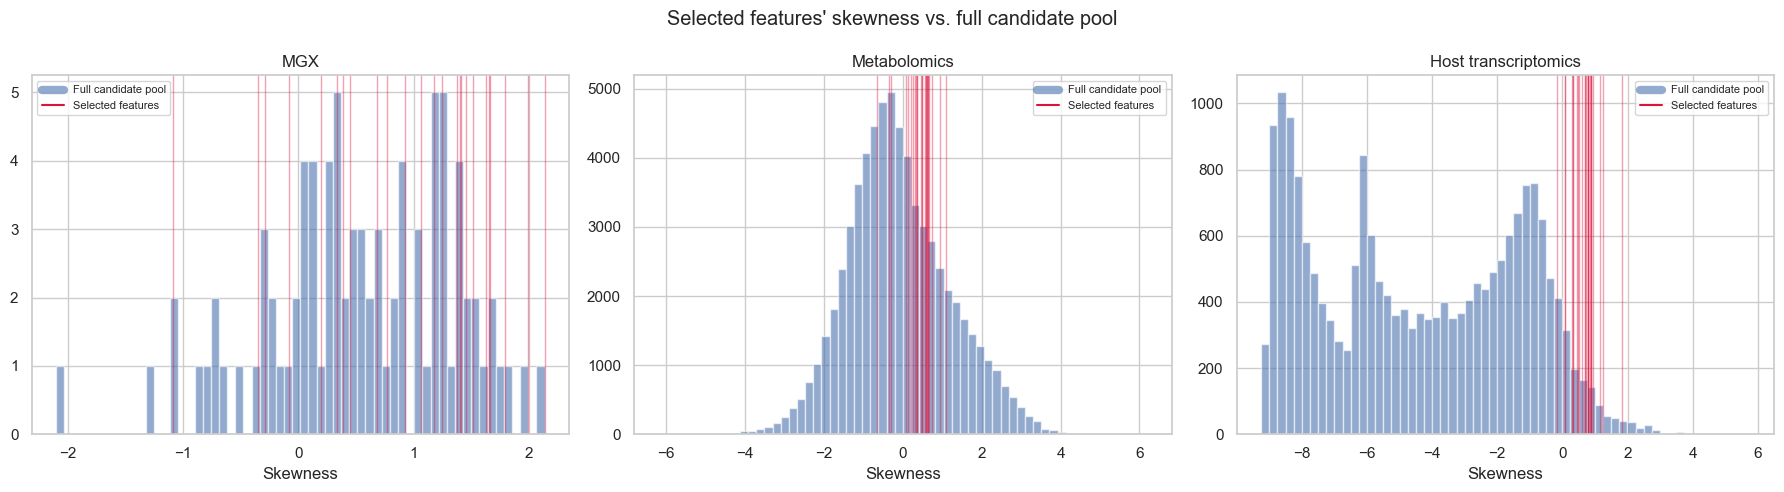

In [38]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, layer in zip(axes, pool_skew.keys()):
    ax.hist(pool_skew[layer].dropna(), bins=60, alpha=0.6, color="C0")
    for v in selected_norm[layer]["skew"]:
        ax.axvline(v, color="crimson", alpha=0.4, linewidth=1)
    ax.set_title(layer)
    ax.set_xlabel("Skewness")
    ax.legend(handles=[
        Line2D([0], [0], color="C0", lw=6, alpha=0.6, label="Full candidate pool"),
        Line2D([0], [0], color="crimson", label="Selected features"),
    ], fontsize=8)
plt.suptitle("Selected features' skewness vs. full candidate pool")
plt.tight_layout()
plt.show()

### 6.3 Summary

Differential-abundance/expression selection does not systematically favour more extreme features than a typical candidate in the same pool, and for two of three layers the selected features are markedly less skewed than the pool average. For MGX, the 25 selected species have a mean absolute skewness of 1.08 against a candidate-pool mean of 0.80 (65th percentile) — a mild bias toward higher skew. For MBX, selected metabolites are less skewed than typical (mean |skew| 0.50 vs. a pool mean of 1.04, 30th percentile), and for HTX the effect is stronger still (mean |skew| 0.69 vs. a pool mean of 4.55, 10th percentile), consistent with DESeq2's Wald test already favouring genes with well-behaved, low-noise expression profiles over the noisier majority of the ~20,000-gene candidate pool. Zero/floor-rate percentiles are close to the pool median for all three layers (55th for MGX, 65th for MBX, and ~50th for HTX, where neither the pool nor the selected genes contain an exact-zero point mass after VST), so selection does not meaningfully concentrate zero-inflated features either. Together with Sections 1-3, this indicates that the non-normality documented throughout this notebook is a property of each layer's raw measurement type, not an artefact introduced by differential-abundance/expression selection preferentially retaining pathological features.

## 7. Pre- vs. post-transform distributional diagnostics

Compares each layer's raw, pre-transform measurement against its already-transformed value from Sections 1–3, for the same DA/DE-selected features and the same participants analysed above. Raw values are loaded directly from `Data/Unprocessed_Other/` and aggregated exactly as in `pipeline.ipynb` (per-participant median across timepoints for MGX/MBX, single baseline biopsy for HTX), stopping immediately before the layer-specific transform (no CLR/pseudocount, no log2, no DESeq2/VST). Any distributional change below is therefore attributable to the transform alone, not to a different cohort or feature set. MBX is read as a filtered subset (25 of the raw file's ~80,000 metabolite rows, streamed in chunks) since the full raw file is too large to load in one pass; MGX and HTX raw files are small enough to load in full.

### 7.1 Load raw pre-transform data

In [39]:
# MGX: raw relative abundance (species-level), same participant-median aggregation as
# pipeline.ipynb Cell 3, restricted to the 25 DA-selected species already loaded as `mgx`.
mgx_raw_all = pd.read_csv(f"{DATA_DIR}/Unprocessed_Other/mgx_species_abundances_raw.tsv", sep="\t", index_col=0)
species_mask = mgx_raw_all.index.str.contains(r"\|s__", regex=True)
mgx_species_raw = mgx_raw_all.loc[species_mask].copy()
mgx_species_raw.index = mgx_species_raw.index.str.extract(r"\|s__(.+)$")[0]
mgx_species_raw = mgx_species_raw.T.astype(float)
mgx_species_raw.index = mgx_species_raw.index.str.replace(r"_P_profile$|_profile$|_P$", "", regex=True)

eid_to_pid = (
    metadata[["External ID", "Participant ID"]]
    .assign(eid_clean=lambda df: df["External ID"].str.replace(r"_P_profile$|_profile$|_P$", "", regex=True))
    .drop_duplicates("eid_clean")
    .set_index("eid_clean")["Participant ID"]
)
mgx_species_raw.index = mgx_species_raw.index.map(eid_to_pid)
mgx_species_raw = mgx_species_raw[mgx_species_raw.index.notna()]
mgx_raw = mgx_species_raw.groupby(mgx_species_raw.index).median()[mgx.columns]
print(f"MGX raw pre-transform: {mgx_raw.shape}")

MGX raw pre-transform: (130, 25)


In [40]:
# MBX: raw metabolite intensity, filtered to the 25 DA-selected metabolites while streaming
# the ~80k-row raw file in chunks (a full load is unnecessary and far slower).
mbx_ids = set(mbx.columns)
mbx_chunks = []
for chunk in pd.read_csv(f"{DATA_DIR}/Unprocessed_Other/mbx_metabolomics_raw.tsv", sep="\t", index_col=0, chunksize=5000):
    match = chunk.loc[chunk.index.isin(mbx_ids)]
    if len(match):
        mbx_chunks.append(match)
mbx_raw_all = pd.concat(mbx_chunks).T.astype(float)

eid_to_pid_mbx = metadata.drop_duplicates("External ID").set_index("External ID")["Participant ID"]
mbx_raw_all.index = mbx_raw_all.index.map(eid_to_pid_mbx)
mbx_raw_all = mbx_raw_all[mbx_raw_all.index.notna()]
mbx_raw = mbx_raw_all.groupby(mbx_raw_all.index).median()[mbx.columns]
print(f"MBX raw pre-transform: {mbx_raw.shape}")

MBX raw pre-transform: (106, 25)


In [41]:
# HTX: raw read counts for the same baseline biopsy per participant selected in
# pipeline.ipynb Cell 5 (fixed anatomical-location priority order), before DESeq2/VST.
LOCATION_PRIORITY = [
    "Rectum", "Ileum", "Sigmoid Colon", "Transverse colon",
    "Descending (left-sided) colon", "Ascending (right-sided) colon",
    "Cecum", "Terminal ileum", "Non-inflamed",
]
htx_samples = (
    metadata[(metadata["data_type"] == "host_transcriptomics") & (metadata["IntervalName"] == "Screening Colonoscopy")]
    .drop_duplicates("External ID")
    .reset_index(drop=True)
)
rna_header = pd.read_csv(f"{DATA_DIR}/Unprocessed_Other/rna_transcriptomics_raw.tsv", sep="\t", nrows=0).columns
htx_samples = htx_samples[htx_samples["External ID"].isin(rna_header)]
htx_samples["location_rank"] = htx_samples["biopsy_location"].apply(
    lambda loc: LOCATION_PRIORITY.index(loc) if loc in LOCATION_PRIORITY else len(LOCATION_PRIORITY)
)
htx_baseline = (
    htx_samples.sort_values(["Participant ID", "location_rank", "External ID"])
    .groupby("Participant ID", sort=True).first().reset_index()
)

usecols = [rna_header[0]] + [c for c in rna_header if c in set(htx_baseline["External ID"])]
rna_raw_genes = pd.read_csv(f"{DATA_DIR}/Unprocessed_Other/rna_transcriptomics_raw.tsv", sep="\t", index_col=0, usecols=usecols)
rna_raw_genes = rna_raw_genes.loc[rna_raw_genes.index.isin(rnaseq.columns)].T.astype(float)
rna_raw_genes.index = htx_baseline.set_index("External ID").loc[rna_raw_genes.index, "Participant ID"]
rna_raw = rna_raw_genes[rnaseq.columns]
print(f"HTX raw pre-transform: {rna_raw.shape}")

HTX raw pre-transform: (90, 25)


### 7.2 Skewness/kurtosis and zero-fraction, raw vs. transformed

Extends the HTX-only zero-fraction finding in Section 3 to all three layers, and adds the skewness/kurtosis/Shapiro-Wilk comparison the earlier sections only reported post-transform.

In [42]:
raw_norm_mgx = normality_summary(mgx_raw)
raw_norm_mbx = normality_summary(mbx_raw)
raw_norm_rna = normality_summary(rna_raw)

raw_zero_mgx = (mgx_raw == 0).mean()
raw_zero_mbx = (mbx_raw == 0).mean()
raw_zero_rna = (rna_raw == 0).mean()


def before_after_row(raw_norm, trans_norm, raw_zero, layer):
    return {
        "layer": layer,
        "n_features": len(raw_norm),
        "raw_mean_abs_skew": raw_norm["skew"].abs().mean(),
        "transformed_mean_abs_skew": trans_norm["skew"].abs().mean(),
        "raw_mean_kurtosis": raw_norm["kurtosis"].mean(),
        "transformed_mean_kurtosis": trans_norm["kurtosis"].mean(),
        "raw_pct_reject_normal": raw_norm["reject_normal"].mean(),
        "transformed_pct_reject_normal": trans_norm["reject_normal"].mean(),
        "raw_mean_zero_fraction": raw_zero.mean(),
    }


before_after = pd.DataFrame([
    before_after_row(raw_norm_mgx, norm_mgx, raw_zero_mgx, "MGX"),
    before_after_row(raw_norm_mbx, norm_mbx, raw_zero_mbx, "MBX"),
    before_after_row(raw_norm_rna, norm_rnaseq, raw_zero_rna, "HTX"),
]).set_index("layer")
before_after.round(3)

,n_features,raw_mean_abs_skew,transformed_mean_abs_skew,raw_mean_kurtosis,transformed_mean_kurtosis,raw_pct_reject_normal,transformed_pct_reject_normal,raw_mean_zero_fraction
layer,,,,,,,,
MGX,25,6.425,1.083,50.870,0.685,1.0,1.00,0.638
MBX,25,4.043,0.498,23.144,-1.033,1.0,0.96,0.286
HTX,25,4.417,0.688,24.056,-0.130,1.0,0.96,0.040


### 7.3 Q-Q plots, raw vs. transformed

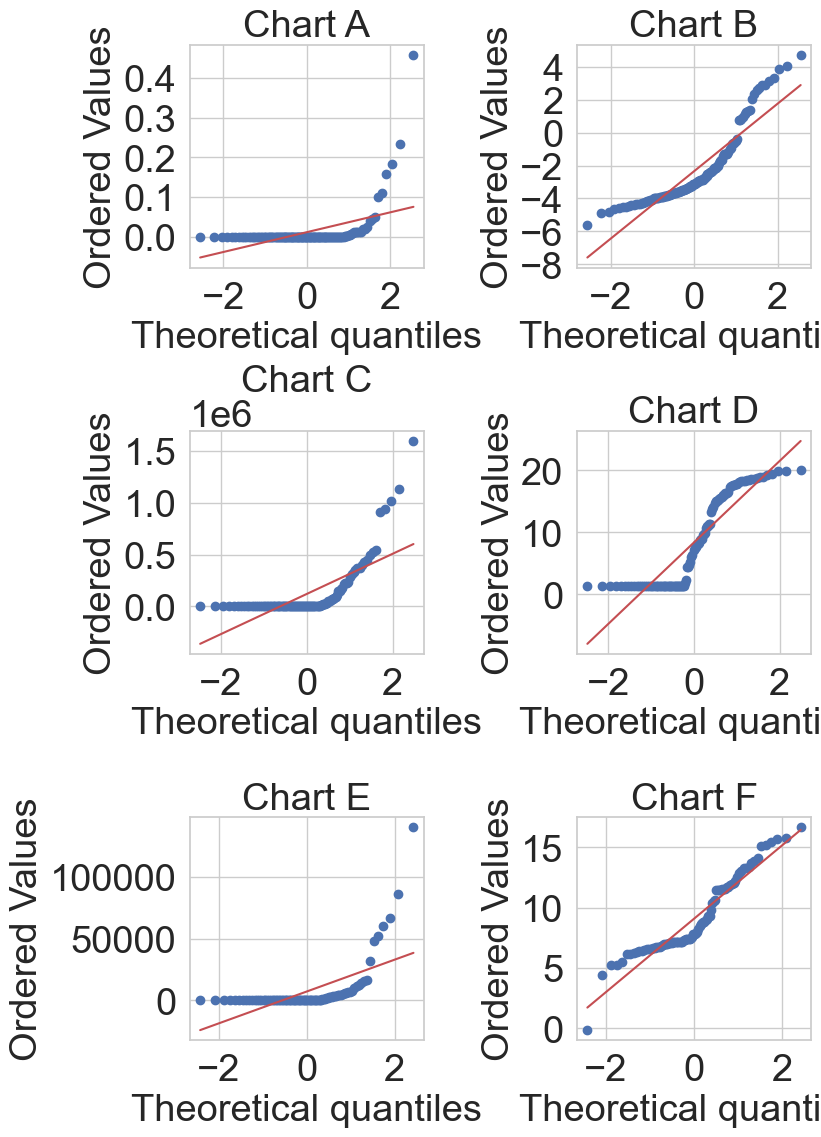

In [43]:
# One representative feature per layer: the feature whose raw skewness is closest to that
# layer's raw median skew, so the example is typical rather than cherry-picked.
layer_data = {
    "MGX": (mgx_raw, mgx, "CLR", raw_norm_mgx),
    "MBX": (mbx_raw, mbx, "log2", raw_norm_mbx),
    "HTX": (rna_raw, rnaseq, "VST", raw_norm_rna),
}
rep_features = {
    layer: raw_norm["skew"].sub(raw_norm["skew"].median()).abs().idxmin()
    for layer, (_, _, _, raw_norm) in layer_data.items()
}

# Panel titles are anonymized to "Chart A".."Chart F" (row-major); the mapping from
# each letter to layer/transform/feature is described in the thesis figure caption
# rather than printed on the chart itself.
# Font sizes below are set so panel text prints at the same size as the thesis body
# text (10pt) once LaTeX scales this figure down to column width.
PAGE_FONT = {"font.size": 27.4, "axes.labelsize": 27.4, "axes.titlesize": 27.4, "xtick.labelsize": 27.4, "ytick.labelsize": 27.4, "legend.fontsize": 27.4}
with plt.rc_context(PAGE_FONT):
    fig, axes = plt.subplots(3, 2, figsize=(9, 12))
    for row, (layer, (raw_df, trans_df, label, _)) in enumerate(layer_data.items()):
        feat = rep_features[layer]
        stats.probplot(raw_df[feat], dist="norm", plot=axes[row, 0])
        axes[row, 0].set_title(f"Chart {chr(65 + row * 2)}")
        stats.probplot(trans_df[feat], dist="norm", plot=axes[row, 1])
        axes[row, 1].set_title(f"Chart {chr(65 + row * 2 + 1)}")
    plt.tight_layout()
    plt.savefig("../images/distribution_shape_before_after_qq.pdf")
plt.show()


### 7.4 Marginal-distribution shape, raw vs. transformed

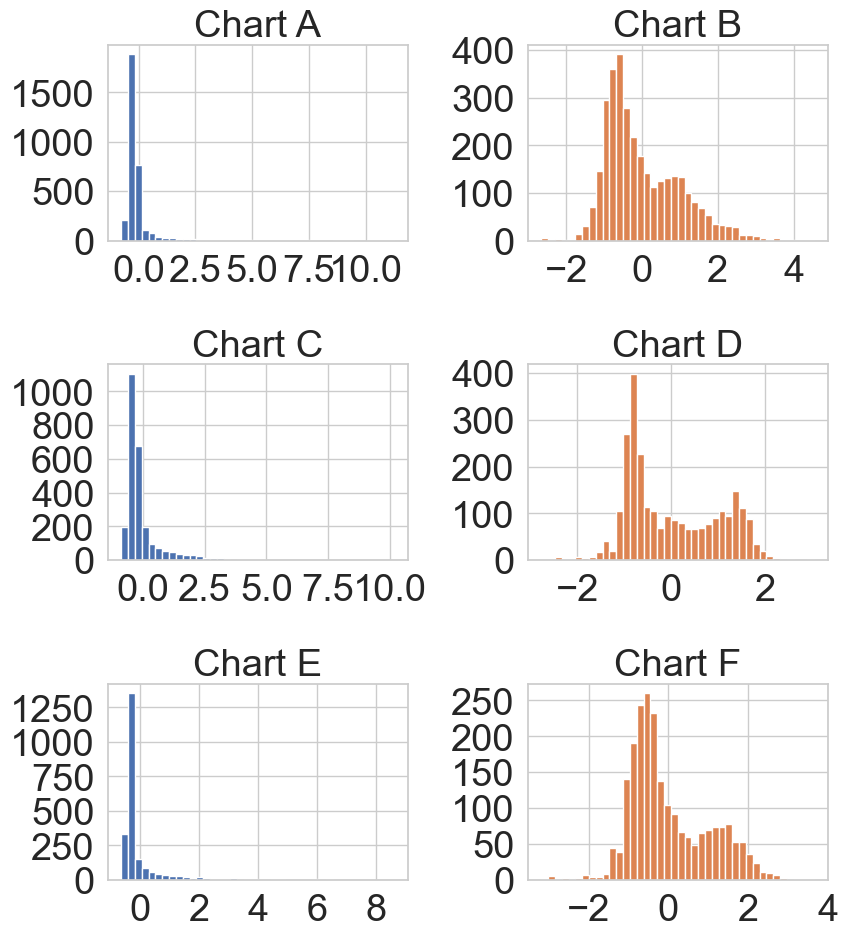

In [44]:
# Overall value distribution (all selected features pooled). Each feature is z-scored
# first so no single large-scale feature (e.g. a highly abundant species/highly expressed
# gene) dominates the pooled histogram; this isolates shape from per-feature scale.
# Panel titles are anonymized to "Chart A".."Chart F" (row-major); the mapping from
# each letter to layer/transform is described in the thesis figure caption rather than
# printed on the chart itself.
# Font sizes below are set so panel text prints at the same size as the thesis body
# text (10pt) once LaTeX scales this figure down to column width.
with plt.rc_context(PAGE_FONT):
    fig, axes = plt.subplots(3, 2, figsize=(9, 10))
    for row, (layer, (raw_df, trans_df, label, _)) in enumerate(layer_data.items()):
        raw_z = ((raw_df - raw_df.mean()) / raw_df.std()).values.flatten()
        trans_z = ((trans_df - trans_df.mean()) / trans_df.std()).values.flatten()
        axes[row, 0].hist(raw_z, bins=40, color="C0")
        axes[row, 0].set_title(f"Chart {chr(65 + row * 2)}")
        axes[row, 1].hist(trans_z, bins=40, color="C1")
        axes[row, 1].set_title(f"Chart {chr(65 + row * 2 + 1)}")
    plt.tight_layout()
    plt.savefig("../images/distribution_shape_before_after.pdf")
plt.show()


### 7.5 Summary

Across all three layers, the raw-to-transformed comparison confirms that each layer-specific transform substantially reduces marginal skewness and kurtosis without achieving full normality. Mean absolute skewness drops from 6.43 to 1.08 for MGX (CLR), from 4.04 to 0.50 for MBX (log2), and from 4.42 to 0.69 for HTX (VST); mean excess kurtosis falls even more sharply, from 24-51 pre-transform to between -1.03 and 0.69 post-transform, removing the extreme heavy-tailedness driven by a small number of very large raw values (the near-vertical departures in the raw Q-Q panels above). Shapiro-Wilk still rejects normality for the large majority of features after transformation (96-100%), consistent with the zero/floor point mass already characterised in Sections 1-3, so the per-feature rejection rate itself barely moves even as skew and kurtosis both improve substantially. Raw zero-fraction (literal zero or below-detection-limit values, prior to any pseudocount/imputation) is highest for MGX (63.8% mean across the 25 selected species) and lowest for HTX (4.0%), with MBX intermediate (28.6%), matching the relative sparsity ordering assumed when each layer's transform was chosen. Together with Sections 1-3, this confirms that CLR, log2, and DESeq2/VST each substantially correct their respective layer's raw distributional pathology, but the residual non-normality driven by zero/floor point masses is what motivates the nonparanormal transform recommended in Section 4.